In [1]:
%matplotlib inline

### 분석

In [16]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import sys
sys.path.insert(0, ".")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import numpy as np
from scipy import stats as sp
from utils.data import get_dataset

# ── 구조 신호 계산 ────────────────────────────────────────────────────────────
def compute_structural_signals(data):
    edge_index = data.edge_index
    sens       = data.sens.float()
    N          = data.num_nodes
    src, dst   = edge_index
    ones       = torch.ones(edge_index.size(1))

    deg = torch.zeros(N).scatter_add_(0, src, ones)

    # w_boundary
    cross       = (sens[src] != sens[dst]).float()
    cross_count = torch.zeros(N).scatter_add_(0, src, cross)
    boundary    = cross_count / (deg + 1e-8)
    boundary_log = torch.log1p(boundary * 10.0)
    w_boundary  = (boundary_log - boundary_log.min()) / \
                  (boundary_log.max() - boundary_log.min() + 1e-8)

    # w_degree
    log_deg   = torch.log1p(deg)
    w_degree  = (log_deg - log_deg.min()) / \
                (log_deg.max() - log_deg.min() + 1e-8)

    # w_lhd
    same       = (sens[src] == sens[dst]).float()
    same_count = torch.zeros(N).scatter_add_(0, src, same)
    local_h    = same_count / (deg + 1e-8)
    lhd        = torch.abs(local_h - local_h.mean())
    w_lhd      = (lhd - lhd.min()) / (lhd.max() - lhd.min() + 1e-8)

    return w_boundary, w_degree, w_lhd, deg

# ── GCN 모델 ─────────────────────────────────────────────────────────────────
class SimpleGCN(nn.Module):
    def __init__(self, in_feats, hidden):
        super().__init__()
        self.conv1 = GCNConv(in_feats, hidden)
        self.conv2 = GCNConv(hidden, 1)
        self.dropout = 0.5

    def forward(self, x, edge_index):
        h = F.relu(self.conv1(x, edge_index))
        h = F.dropout(h, p=self.dropout, training=self.training)
        return self.conv2(h, edge_index).view(-1), h

# ── GCN 학습 및 불확실성 계산 ─────────────────────────────────────────────────
def train_and_get_uncertainty(data, epochs=300, seed=42):
    torch.manual_seed(seed)

    # y remap
    y_raw      = data.y.float()
    valid_mask = (y_raw == 0.0) | (y_raw == 1.0)
    y          = y_raw.clone()

    N  = data.num_nodes
    x  = data.x.float()
    ei = data.edge_index

    idx          = torch.randperm(N, generator=torch.Generator().manual_seed(seed))
    train_mask   = torch.zeros(N, dtype=torch.bool)
    train_mask[idx[:int(0.6 * N)]] = True
    train_mask   = train_mask & valid_mask

    model     = SimpleGCN(x.size(1), 64)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)

    print(f"  Training {epochs} epochs...")
    for ep in range(epochs):
        model.train()
        optimizer.zero_grad()
        out, _ = model(x, ei)
        loss   = F.binary_cross_entropy_with_logits(
            out[train_mask], y[train_mask])
        loss.backward()
        optimizer.step()
        if (ep + 1) % 100 == 0:
            print(f"    ep {ep+1}/{epochs}  loss={loss.item():.4f}")

    # 예측 불확실성 (entropy)
    model.eval()
    with torch.no_grad():
        out, _ = model(x, ei)
    p   = torch.sigmoid(out).clamp(1e-6, 1 - 1e-6)
    unc = -(p * p.log() + (1 - p) * (1 - p).log())
    unc = (unc - unc.min()) / (unc.max() - unc.min() + 1e-8)

    # per-node fairness violation (counterfactual)
    sens = data.sens.float()
    fv   = torch.zeros(N)
    for i in range(N):
        if not valid_mask[i]:
            continue
        yi = y[i].item()
        si = sens[i].item()
        opp_mask = (sens != si) & (y == yi) & valid_mask
        if opp_mask.sum() == 0:
            continue
        prob_i   = p[i]
        prob_opp = p[opp_mask].mean()
        fv[i]    = (prob_i - prob_opp).abs()

    return unc.detach(), fv.detach(), valid_mask

# ── 사분면 분석 ───────────────────────────────────────────────────────────────
def quadrant_analysis(sr, unc, fv, valid_mask=None):
    if valid_mask is not None:
        sr  = sr[valid_mask]
        unc = unc[valid_mask]
        fv  = fv[valid_mask]

    sr_np  = sr.numpy()
    ent_np = unc.numpy()
    fv_np  = fv.numpy()

    sr_med  = np.median(sr_np)
    ent_med = np.median(ent_np)

    masks = {
        'LL': (sr_np <= sr_med) & (ent_np <= ent_med),
        'HL': (sr_np >  sr_med) & (ent_np <= ent_med),
        'LH': (sr_np <= sr_med) & (ent_np >  ent_med),
        'HH': (sr_np >  sr_med) & (ent_np >  ent_med),
    }
    stats = {k: float(fv_np[m].mean()) for k, m in masks.items()}
    return stats, sr_med, ent_med, sr_np, ent_np, fv_np

# ── 신호 간 상관관계 ──────────────────────────────────────────────────────────
def signal_correlations(w_boundary, w_degree, w_lhd, unc, fv, valid_mask):
    wb  = w_boundary[valid_mask].numpy()
    wd  = w_degree[valid_mask].numpy()
    wl  = w_lhd[valid_mask].numpy()
    u   = unc[valid_mask].numpy()
    fv_ = fv[valid_mask].numpy()

    r_bdry_lhd,  _ = sp.pearsonr(wb, wl)
    r_bdry_unc,  _ = sp.pearsonr(wb, u)
    r_deg_unc,   _ = sp.pearsonr(wd, u)
    r_bdry_fv,   _ = sp.pearsonr(wb, fv_)
    r_unc_fv,    _ = sp.pearsonr(u,  fv_)
    r_interact,  _ = sp.pearsonr(wb * u, fv_)

    return {
        'r_bdry_lhd':  r_bdry_lhd,
        'r_bdry_unc':  r_bdry_unc,
        'r_deg_unc':   r_deg_unc,
        'r_bdry_fv':   r_bdry_fv,
        'r_unc_fv':    r_unc_fv,
        'r_interact':  r_interact,
    }

# ── minority enrichment 분석 ──────────────────────────────────────────────────
def enrichment_analysis(signal, sens, threshold_q=0.7):
    """
    상위 (1-q) 노드 중 minority(sens=1) 비율 vs 전체 minority 비율
    """
    thr      = np.quantile(signal.numpy(), threshold_q)
    high_mask = signal.numpy() > thr
    global_minority = float(sens.float().mean().item())
    if high_mask.sum() == 0:
        return 0.0, global_minority, 1.0
    local_minority  = float(sens[high_mask].float().mean().item())
    enrichment      = local_minority / (global_minority + 1e-8)
    return local_minority, global_minority, enrichment

# ── uncertainty diff 분석 ─────────────────────────────────────────────────────
def uncertainty_diff(signal, unc, threshold_q=0.7):
    """
    상위 노드 vs 나머지 노드 간 uncertainty 평균 차이 + t-test
    """
    thr       = np.quantile(signal.numpy(), threshold_q)
    high_mask = signal.numpy() > thr
    low_mask  = ~high_mask
    if high_mask.sum() == 0 or low_mask.sum() == 0:
        return 0.0, 1.0
    diff    = float(unc[high_mask].mean() - unc[low_mask].mean())
    t, p    = sp.ttest_ind(
        unc[high_mask].numpy(), unc[low_mask].numpy())
    return diff, float(p)

# ── 메인 실행 ─────────────────────────────────────────────────────────────────
DATASETS = ["pokec_z", "pokec_n", "credit", "recidivism", "income", "german", "nba"]

all_results = {}

for name in DATASETS:
    print(f"\n{'='*60}")
    print(f"Dataset: {name}")
    data, sens_idx, x_min, x_max = get_dataset(name, path="./data")

    # y=-1 노드 제외 (nba)
    valid_y = (data.y != -1)
    if not valid_y.all():
        from torch_geometric.utils import subgraph
        vidx = valid_y.nonzero(as_tuple=True)[0]
        new_ei, _ = subgraph(vidx, data.edge_index,
                             relabel_nodes=True, num_nodes=data.num_nodes)
        data.x    = data.x[vidx]
        data.y    = data.y[vidx]
        data.sens = data.sens[vidx]
        data.edge_index = new_ei
        print(f"  y=-1 제외 후 nodes: {data.num_nodes}")

    print(f"  nodes={data.num_nodes}, edges={data.edge_index.size(1)}")
    print(f"  y unique={data.y.unique().tolist()}")
    print(f"  sens unique={data.sens.unique().tolist()[:5]}")

    # 구조 신호
    w_boundary, w_degree, w_lhd, deg = compute_structural_signals(data)

    # GCN 학습 + 불확실성
    unc, fv, valid_mask = train_and_get_uncertainty(data)

    # 사분면 분석 (SR = w_boundary 기준)
    quad_stats, sr_med, ent_med, sr_np, ent_np, fv_np = \
        quadrant_analysis(w_boundary, unc, fv, valid_mask)

    # 신호 간 상관관계
    corrs = signal_correlations(w_boundary, w_degree, w_lhd, unc, fv, valid_mask)

    # enrichment (w_boundary, w_degree, w_lhd)
    enrich_bdry = enrichment_analysis(w_boundary, data.sens)
    enrich_deg  = enrichment_analysis(w_degree,   data.sens)
    enrich_lhd  = enrichment_analysis(w_lhd,      data.sens)

    # uncertainty diff
    unc_diff_bdry = uncertainty_diff(w_boundary, unc)
    unc_diff_deg  = uncertainty_diff(w_degree,   unc)
    unc_diff_lhd  = uncertainty_diff(w_lhd,      unc)

    # 결과 출력
    print(f"\n  --- Quadrant FV (w_boundary vs uncertainty) ---")
    print(f"  Q1 LL: {quad_stats['LL']:.4f}  Q2 HL: {quad_stats['HL']:.4f}")
    print(f"  Q3 LH: {quad_stats['LH']:.4f}  Q4 HH: {quad_stats['HH']:.4f}")
    max_q = max(quad_stats, key=quad_stats.get)
    min_q = min(quad_stats, key=quad_stats.get)
    gain  = (quad_stats[max_q] / (quad_stats[min_q] + 1e-8) - 1) * 100
    print(f"  Max quadrant: {max_q} ({quad_stats[max_q]:.4f}), gain vs min: +{gain:.1f}%")

    print(f"\n  --- Signal Correlations ---")
    print(f"  r(bdry, lhd)  = {corrs['r_bdry_lhd']:.4f}  "
          f"← lhd와 boundary 중복 여부")
    print(f"  r(bdry, unc)  = {corrs['r_bdry_unc']:.4f}  "
          f"← 구조와 불확실성 독립 여부")
    print(f"  r(deg,  unc)  = {corrs['r_deg_unc']:.4f}")
    print(f"  r(bdry, fv)   = {corrs['r_bdry_fv']:.4f}")
    print(f"  r(unc,  fv)   = {corrs['r_unc_fv']:.4f}")
    print(f"  r(bdry*unc,fv)= {corrs['r_interact']:.4f}  "
          f"← 교차 신호 설명력")

    print(f"\n  --- Enrichment (top 30% nodes) ---")
    print(f"  w_boundary: local={enrich_bdry[0]:.3f}, "
          f"global={enrich_bdry[1]:.3f}, enrich={enrich_bdry[2]:.2f}x")
    print(f"  w_degree:   local={enrich_deg[0]:.3f}, "
          f"global={enrich_deg[1]:.3f}, enrich={enrich_deg[2]:.2f}x")
    print(f"  w_lhd:      local={enrich_lhd[0]:.3f}, "
          f"global={enrich_lhd[1]:.3f}, enrich={enrich_lhd[2]:.2f}x")

    print(f"\n  --- Uncertainty Diff (top 30% vs rest) ---")
    print(f"  w_boundary: diff={unc_diff_bdry[0]:+.4f}, p={unc_diff_bdry[1]:.4f}")
    print(f"  w_degree:   diff={unc_diff_deg[0]:+.4f},  p={unc_diff_deg[1]:.4f}")
    print(f"  w_lhd:      diff={unc_diff_lhd[0]:+.4f},  p={unc_diff_lhd[1]:.4f}")

    # 저장
    all_results[name] = {
        'quad_stats':    quad_stats,
        'corrs':         corrs,
        'enrich_bdry':   enrich_bdry,
        'enrich_deg':    enrich_deg,
        'enrich_lhd':    enrich_lhd,
        'unc_diff_bdry': unc_diff_bdry,
        'unc_diff_deg':  unc_diff_deg,
        'unc_diff_lhd':  unc_diff_lhd,
        'gain':          gain,
        'max_q':         max_q,
    }
    np.savez(f"analysis_{name}.npz",
             w_boundary  = w_boundary.numpy(),
             w_degree    = w_degree.numpy(),
             w_lhd       = w_lhd.numpy(),
             uncertainty = unc.numpy(),
             fairness_violation = fv.numpy(),
             valid_mask  = valid_mask.numpy(),
             sens        = data.sens.numpy(),
             y           = data.y.numpy())
    print(f"  Saved: analysis_{name}.npz")

# ── 전체 요약 출력 ────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("SUMMARY")
print(f"{'='*60}")
print(f"{'Dataset':<12} {'Max Q':<6} {'Gain%':>7} "
      f"{'r(bdry,lhd)':>12} {'r(bdry,unc)':>12} "
      f"{'r(b*u,fv)':>10} {'enrich_bdry':>12}")
for name, r in all_results.items():
    print(f"{name:<12} {r['max_q']:<6} {r['gain']:>7.1f}% "
          f"{r['corrs']['r_bdry_lhd']:>12.4f} "
          f"{r['corrs']['r_bdry_unc']:>12.4f} "
          f"{r['corrs']['r_interact']:>10.4f} "
          f"{r['enrich_bdry'][2]:>12.2f}x")


Dataset: pokec_z
  y=-1 제외 후 nodes: 10262
  nodes=10262, edges=51786
  y unique=[0.0, 1.0]
  sens unique=[0.0, 1.0]
  Training 300 epochs...
    ep 100/300  loss=0.5009
    ep 200/300  loss=0.4503
    ep 300/300  loss=0.4090

  --- Quadrant FV (w_boundary vs uncertainty) ---
  Q1 LL: 0.2508  Q2 HL: 0.2277
  Q3 LH: 0.1541  Q4 HH: 0.1684
  Max quadrant: LL (0.2508), gain vs min: +62.7%

  --- Signal Correlations ---
  r(bdry, lhd)  = 0.9281  ← lhd와 boundary 중복 여부
  r(bdry, unc)  = 0.0449  ← 구조와 불확실성 독립 여부
  r(deg,  unc)  = 0.4786
  r(bdry, fv)   = -0.0203
  r(unc,  fv)   = -0.3952
  r(bdry*unc,fv)= -0.0642  ← 교차 신호 설명력

  --- Enrichment (top 30% nodes) ---
  w_boundary: local=0.484, global=0.355, enrich=1.36x
  w_degree:   local=0.422, global=0.355, enrich=1.19x
  w_lhd:      local=0.479, global=0.355, enrich=1.35x

  --- Uncertainty Diff (top 30% vs rest) ---
  w_boundary: diff=+0.0916, p=0.0000
  w_degree:   diff=+0.2393,  p=0.0000
  w_lhd:      diff=+0.0832,  p=0.0000
  Saved: analys

### 데이터셋 확인

In [36]:
from utils.data import get_dataset

for name in ["pokec_z", "pokec_n", "credit", "recidivism", "income", "german", "nba"]:
    data, sens_idx, x_min, x_max = get_dataset(name, path="./data")
    print(
        name,
        "nodes:", data.num_nodes,
        "edges:", data.edge_index.size(1),
        "features:", data.x.size(1),
        "sens_idx:", sens_idx,
        "labels:", sorted(data.y.unique().tolist()),
        "sens:", sorted(data.sens.unique().tolist())[:10],
    )

pokec_z nodes: 67796 edges: 1303712 features: 277 sens_idx: 276 labels: [-1.0, 0.0, 1.0] sens: [0.0, 1.0]
pokec_n nodes: 66569 edges: 1100663 features: 266 sens_idx: 265 labels: [-1.0, 0.0, 1.0] sens: [0.0, 1.0]
credit nodes: 30000 edges: 2873716 features: 13 sens_idx: 1 labels: [0.0, 1.0] sens: [0, 1]
recidivism nodes: 18876 edges: 642616 features: 18 sens_idx: 0 labels: [0.0, 1.0] sens: [0, 1]
income nodes: 14821 edges: 100483 features: 14 sens_idx: 8 labels: [0.0, 1.0] sens: [0, 1]
german nodes: 1000 edges: 44484 features: 27 sens_idx: 0 labels: [0.0, 1.0] sens: [0, 1]
nba nodes: 403 edges: 21645 features: 96 sens_idx: 95 labels: [-1.0, 0.0, 1.0] sens: [0.0, 1.0]


In [46]:
import os
import pandas as pd
import torch

from utils.data import get_dataset

DATASETS = [
    "pokec_z", "pokec_z_g", "pokec_n", "pokec_n_g",
    "credit", "recidivism", "income", "german", "nba"
]

DATASET_META = {
    "pokec_z": {
        "csv": "./data/pokec/region_job.csv",
        "label_col": "I_am_working_in_field",
        "sens_col": "region",
    },
    "pokec_z_g": {
        "csv": "./data/pokec/region_job.csv",
        "label_col": "I_am_working_in_field",
        "sens_col": "gender",
    },
    "pokec_n": {
        "csv": "./data/pokec/region_job_2.csv",
        "label_col": "I_am_working_in_field",
        "sens_col": "region",
    },
    "pokec_n_g": {
        "csv": "./data/pokec/region_job_2.csv",
        "label_col": "I_am_working_in_field",
        "sens_col": "gender",
    },
    "credit": {
        "csv": "./data/credit/credit.csv",
        "label_col": "NoDefaultNextMonth",
        "sens_col": "Age",
    },
    "recidivism": {
        "csv": "./data/bail/bail.csv",
        "label_col": "RECID",
        "sens_col": "WHITE",
    },
    "income": {
        "csv": "./data/income/income.csv",
        "label_col": "income",
        "sens_col": "race",
    },
    "german": {
        "csv": "./data/german/german.csv",
        "label_col": "GoodCustomer",
        "sens_col": "Gender",
    },
    "nba": {
        "csv": "./data/NBA/nba.csv",
        "label_col": "SALARY",
        "sens_col": "country",
    },
}

def value_counts_tensor(t):
    values, counts = torch.unique(t.cpu(), return_counts=True)
    return {str(v.item()): int(c.item()) for v, c in zip(values, counts)}

def inspect_loaded_dataset(name):
    data, sens_idx, x_min, x_max = get_dataset(name)

    print("=" * 80)
    print(f"[Loaded dataset] {name}")
    print(f"num_nodes: {data.num_nodes}")
    print(f"num_edges: {data.edge_index.size(1)}")
    print(f"num_features: {data.x.size(1)}")
    print(f"sens_idx: {sens_idx}")

    print("\nLoaded label distribution data.y:")
    print(value_counts_tensor(data.y))

    valid_label = (data.y == 0) | (data.y == 1)
    print("Valid label distribution data.y in {0,1}:")
    print(value_counts_tensor(data.y[valid_label]))
    print(f"Invalid label count: {(~valid_label).sum().item()}")

    print("\nLoaded sensitive attribute distribution data.sens:")
    print(value_counts_tensor(data.sens))

    for split_name in ["train_mask", "val_mask", "test_mask"]:
        mask = getattr(data, split_name)
        split_valid = mask & valid_label
        print(f"\n{split_name}: {int(mask.sum())} nodes")
        print(f"{split_name} valid labels:")
        print(value_counts_tensor(data.y[split_valid]))

def inspect_raw_csv(name):
    meta = DATASET_META[name]
    path = meta["csv"]
    label_col = meta["label_col"]
    sens_col = meta["sens_col"]

    print("\n[Raw CSV]")
    print(f"path: {path}")
    print(f"label_col: {label_col}")
    print(f"sens_col: {sens_col}")

    if not os.path.exists(path):
        print("CSV not found.")
        return

    df = pd.read_csv(path)

    print("\nRaw label value counts:")
    print(df[label_col].value_counts(dropna=False).sort_index())

    print("\nRaw sensitive value counts:")
    print(df[sens_col].value_counts(dropna=False).sort_index())

    print("\nRaw label x sensitive crosstab:")
    print(pd.crosstab(df[label_col], df[sens_col], dropna=False))

for name in DATASETS:
    inspect_loaded_dataset(name)
    inspect_raw_csv(name)

[Loaded dataset] pokec_z
num_nodes: 67796
num_edges: 1303712
num_features: 277
sens_idx: 276

Loaded label distribution data.y:
{'-1.0': 57534, '0.0': 4764, '1.0': 5498}
Valid label distribution data.y in {0,1}:
{'0.0': 4764, '1.0': 5498}
Invalid label count: 57534

Loaded sensitive attribute distribution data.sens:
{'0.0': 43962, '1.0': 23834}

train_mask: 500 nodes
train_mask valid labels:
{'0.0': 244, '1.0': 256}

val_mask: 2565 nodes
val_mask valid labels:
{'0.0': 1149, '1.0': 1416}

test_mask: 2566 nodes
test_mask valid labels:
{'0.0': 1191, '1.0': 1375}

[Raw CSV]
path: ./data/pokec/region_job.csv
label_col: I_am_working_in_field
sens_col: region

Raw label value counts:
I_am_working_in_field
-1    57534
 0     4764
 1     1964
 2     1266
 3     1287
 4      981
Name: count, dtype: int64

Raw sensitive value counts:
region
0    43962
1    23834
Name: count, dtype: int64

Raw label x sensitive crosstab:
region                     0      1
I_am_working_in_field              
-1   

In [23]:
from utils.data import get_dataset
import torch
import torch_geometric

results = {}
for name in ["pokec_z", "pokec_n", "credit", "recidivism", "income", "german", "nba"]:
    data, sens_idx, x_min, x_max = get_dataset(name, path="./data")
    
    # GCN으로 예측 불확실성 계산
    from torch_geometric.nn import GCNConv
    import torch.nn.functional as F
    
    # 구조적 위험 계산 (boundary risk + degree)
    edge_index = data.edge_index
    sens = data.sens
    
    # boundary risk: 이웃 중 다른 sensitive group 비율
    row, col = edge_index
    same_group = (sens[row] == sens[col]).float()
    degree = torch.zeros(data.num_nodes).scatter_add(0, row, torch.ones(row.size(0)))
    boundary_risk = 1 - torch.zeros(data.num_nodes).scatter_add(
        0, row, same_group) / (degree + 1e-8)
    
    results[name] = {
        "num_nodes": data.num_nodes,
        "boundary_risk": boundary_risk.tolist()[:10],  # 샘플
        "degree_mean": degree.mean().item(),
    }
    print(f"{name}: nodes={data.num_nodes}, "
          f"boundary_risk_mean={boundary_risk.mean():.3f}, "
          f"degree_mean={degree.mean():.1f}")

pokec_z: nodes=67796, boundary_risk_mean=0.062, degree_mean=19.2
pokec_n: nodes=66569, boundary_risk_mean=0.055, degree_mean=16.5
credit: nodes=30000, boundary_risk_mean=0.060, degree_mean=95.8
recidivism: nodes=18876, boundary_risk_mean=0.458, degree_mean=34.0
income: nodes=14821, boundary_risk_mean=0.101, degree_mean=6.8
german: nodes=1000, boundary_risk_mean=0.185, degree_mean=44.5
nba: nodes=403, boundary_risk_mean=0.274, degree_mean=53.7


In [17]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import sys
sys.path.insert(0, ".")

import torch
import torch.nn as nn
import numpy as np
from utils.data import get_dataset
from utils.model import (
    FairGate, compute_fiw_weights,
    _compute_structural_signals,
    _estimate_entropy_uncertainty,
    _compute_loss_based_signal,
)

def extract_fiw_signals(name, seed=42):
    torch.manual_seed(seed)
    device = torch.device("cpu")

    data, sens_idx, x_min, x_max = get_dataset(name, path="./data")
    data = data.to(device)

    model = FairGate(
        in_feats   = data.x.size(1),
        h_feats    = 128,
        device     = device,
        backbone   = "GCN",
        dropout    = 0.5,
        lambda_fair= 0.05,
        sbrs_quantile = 0.7,
        fips_lam   = 1.0,
        warm_up    = 200,
    )

    optimizer = torch.optim.Adam(
        model.model.parameters(), lr=1e-3, weight_decay=1e-5)
    criterion = nn.BCEWithLogitsLoss()

    # warm-up 200 epoch
    print(f"[{name}] Warm-up 200 epochs (CPU)...")
    model._init_weights_warmup(data)
    for ep in range(200):
        model._train_step(data, optimizer, criterion, lam=0.0)
        if (ep + 1) % 50 == 0:
            print(f"  ep {ep+1}/200")

    # ── 신호 추출 ──────────────────────────────────────────────
    model.model.eval()
    data.alpha_beta_mode = "variance"

    sig        = _compute_structural_signals(data)
    w_boundary = sig["w_boundary"].cpu()
    w_degree   = sig["w_degree"].cpu()

    # α, β (variance 방식)
    vars_ = torch.stack([w_boundary.var(), w_degree.var()])
    coefs = vars_ / (vars_.sum() + 1e-8)
    alpha, beta = coefs[0].item(), coefs[1].item()

    struct_score = alpha * w_boundary + beta * w_degree
    struct_score = (struct_score - struct_score.min()) / \
                   (struct_score.max() - struct_score.min() + 1e-8)

    u   = _estimate_entropy_uncertainty(model.model, data).cpu()
    fv  = _compute_loss_based_signal(model.model, data).cpu()

    fiw, meta = compute_fiw_weights(
        data,
        model              = model.model,
        sbrs_quantile      = 0.7,
        fips_lam           = 1.0,
        gating_mode_override = "adaptive",
        fiw_weight_mode    = "continuous_uncert",
    )
    fiw  = fiw.cpu()
    gate = (fiw > 0.5 + 1e-4)

    # ── 사분면 분석 ────────────────────────────────────────────
    sr_np  = struct_score.numpy()
    ent_np = u.numpy()
    fv_np  = fv.numpy()

    sr_med  = np.median(sr_np)
    ent_med = np.median(ent_np)
    q_ll = (sr_np <= sr_med) & (ent_np <= ent_med)
    q_hl = (sr_np >  sr_med) & (ent_np <= ent_med)
    q_lh = (sr_np <= sr_med) & (ent_np >  ent_med)
    q_hh = (sr_np >  sr_med) & (ent_np >  ent_med)

    print(f"\n[{name}] alpha={alpha:.3f} beta={beta:.3f}")
    print(f"[{name}] gating={meta['gating_mode']}  "
          f"gated={meta['gated']}/{meta['n_total']}")
    print(f"  FV unique={len(np.unique(fv_np))}  "
          f"min={fv_np.min():.4f}  max={fv_np.max():.4f}")
    print(f"  Quadrant FV (mean):")
    print(f"  Q1 Low SR  / Low Unc  : {fv_np[q_ll].mean():.4f}  (n={q_ll.sum()})")
    print(f"  Q2 High SR / Low Unc  : {fv_np[q_hl].mean():.4f}  (n={q_hl.sum()})")
    print(f"  Q3 Low SR  / High Unc : {fv_np[q_lh].mean():.4f}  (n={q_lh.sum()})")
    print(f"  Q4 High SR / High Unc : {fv_np[q_hh].mean():.4f}  (n={q_hh.sum()})")

    np.savez(f"fig_fairgate_{name}.npz",
             struct_score = sr_np,
             entropy      = ent_np,
             fairness_loss= fv_np,
             fiw          = fiw.numpy(),
             gate         = gate.numpy(),
             sens         = data.sens.cpu().numpy(),
             y            = data.y.cpu().numpy(),
             alpha        = np.array(alpha),
             beta         = np.array(beta))
    print(f"  Saved: fig_fairgate_{name}.npz\n")

for name in [
    # "recidivism", "german", "credit",
    "income", "pokec_z", "pokec_n",
    ]:
    extract_fiw_signals(name)

[income] Warm-up 200 epochs (CPU)...
[GCN/FairGate] Phase 1 (structure-only) | homophily=0.884 gating=adaptive_boundary | alpha(boundary)=0.923 beta(degree)=0.077 | thr_boundary=0.317 | gated=4446/14821 (30.0%) | unc=none | wmode=continuous_uncert | w_mean=0.652 w_std=0.317
  ep 50/200
  ep 100/200
  ep 150/200
  ep 200/200

[income] alpha=0.923 beta=0.077
[income] gating=adaptive_boundary  gated=4446/14821
  FV unique=12285  min=0.0000  max=1.0000
  Quadrant FV (mean):
  Q1 Low SR  / Low Unc  : 0.0443  (n=4218)
  Q2 High SR / Low Unc  : 0.0714  (n=3194)
  Q3 Low SR  / High Unc : 0.0976  (n=3654)
  Q4 High SR / High Unc : 0.1370  (n=3755)
  Saved: fig_fairgate_income.npz

[pokec_z] Warm-up 200 epochs (CPU)...
[GCN/FairGate] Phase 1 (structure-only) | homophily=0.953 gating=adaptive_boundary | alpha(boundary)=0.547 beta(degree)=0.453 | thr_boundary=0.128 | gated=20339/67796 (30.0%) | unc=none | wmode=continuous_uncert | w_mean=0.568 w_std=0.152
  ep 50/200
  ep 100/200
  ep 150/200
  ep

In [14]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import sys
sys.path.insert(0, ".")

import torch
import torch.nn as nn
import numpy as np
from utils.data import get_dataset
from utils.model import (
    FairGate, compute_fiw_weights,
    _compute_structural_signals,
    _estimate_entropy_uncertainty,
    _compute_loss_based_signal,
)

def extract_fiw_signals_nba(seed=42):
    torch.manual_seed(seed)
    device = torch.device("cpu")
    name   = "nba"

    data, sens_idx, x_min, x_max = get_dataset(name, path="./data")

    # ── y=-1 노드 제외 ────────────────────────────────────────
    valid_mask = (data.y != -1)
    valid_idx  = valid_mask.nonzero(as_tuple=True)[0]
    print(f"[nba] 전체 노드: {data.num_nodes}  "
          f"y=-1 제외 후: {valid_idx.numel()}")

    # subgraph로 유효 노드만 추출
    from torch_geometric.utils import subgraph
    new_edge_index, _ = subgraph(
        valid_idx, data.edge_index,
        relabel_nodes=True, num_nodes=data.num_nodes
    )
    data.x          = data.x[valid_idx]
    data.y          = data.y[valid_idx]
    data.sens       = data.sens[valid_idx]
    data.edge_index = new_edge_index

    # mask도 재구성
    if hasattr(data, 'train_mask'):
        data.train_mask = data.train_mask[valid_idx]
        data.val_mask   = data.val_mask[valid_idx]
        data.test_mask  = data.test_mask[valid_idx]

    data = data.to(device)
    print(f"[nba] 처리 후 노드: {data.num_nodes}, "
          f"엣지: {data.edge_index.size(1)}")
    print(f"[nba] y unique: {data.y.unique().tolist()}")
    print(f"[nba] sens unique: {data.sens.unique().tolist()}")

    # ── FairGate warm-up ──────────────────────────────────────
    model = FairGate(
        in_feats      = data.x.size(1),
        h_feats       = 128,
        device        = device,
        backbone      = "GCN",
        dropout       = 0.5,
        lambda_fair   = 0.05,
        sbrs_quantile = 0.7,
        fips_lam      = 1.0,
        warm_up       = 200,
    )

    optimizer = torch.optim.Adam(
        model.model.parameters(), lr=1e-3, weight_decay=1e-5)
    criterion = nn.BCEWithLogitsLoss()

    print(f"[nba] Warm-up 200 epochs (CPU)...")
    model._init_weights_warmup(data)
    for ep in range(200):
        model._train_step(data, optimizer, criterion, lam=0.0)
        if (ep + 1) % 50 == 0:
            print(f"  ep {ep+1}/200")

    # ── 신호 추출 ──────────────────────────────────────────────
    model.model.eval()
    data.alpha_beta_mode = "variance"

    sig        = _compute_structural_signals(data)
    w_boundary = sig["w_boundary"].cpu()
    w_degree   = sig["w_degree"].cpu()

    vars_ = torch.stack([w_boundary.var(), w_degree.var()])
    coefs = vars_ / (vars_.sum() + 1e-8)
    alpha, beta = coefs[0].item(), coefs[1].item()

    struct_score = alpha * w_boundary + beta * w_degree
    struct_score = (struct_score - struct_score.min()) / \
                   (struct_score.max() - struct_score.min() + 1e-8)

    u  = _estimate_entropy_uncertainty(model.model, data).cpu()
    fv = _compute_loss_based_signal(model.model, data).cpu()

    fiw, meta = compute_fiw_weights(
        data,
        model                = model.model,
        sbrs_quantile        = 0.7,
        fips_lam             = 1.0,
        gating_mode_override = "adaptive",
        fiw_weight_mode      = "continuous_uncert",
    )
    fiw  = fiw.cpu()
    gate = (fiw > 0.5 + 1e-4)

    # ── 사분면 분석 ────────────────────────────────────────────
    sr_np  = struct_score.numpy()
    ent_np = u.numpy()
    fv_np  = fv.numpy()

    sr_med  = np.median(sr_np)
    ent_med = np.median(ent_np)
    q_ll = (sr_np <= sr_med) & (ent_np <= ent_med)
    q_hl = (sr_np >  sr_med) & (ent_np <= ent_med)
    q_lh = (sr_np <= sr_med) & (ent_np >  ent_med)
    q_hh = (sr_np >  sr_med) & (ent_np >  ent_med)

    stats = {
        'LL': fv_np[q_ll].mean(),
        'HL': fv_np[q_hl].mean(),
        'LH': fv_np[q_lh].mean(),
        'HH': fv_np[q_hh].mean(),
    }

    print(f"\n[nba] alpha={alpha:.3f}, beta={beta:.3f}")
    print(f"[nba] gating={meta['gating_mode']}, "
          f"gated={meta['gated']}/{meta['n_total']}")
    print(f"  FV unique={len(np.unique(fv_np))}  "
          f"min={fv_np.min():.4f}  max={fv_np.max():.4f}")
    print(f"  Quadrant FV (mean):")
    print(f"  Q1 Low SR  / Low Unc  : {stats['LL']:.4f}  (n={q_ll.sum()})")
    print(f"  Q2 High SR / Low Unc  : {stats['HL']:.4f}  (n={q_hl.sum()})")
    print(f"  Q3 Low SR  / High Unc : {stats['LH']:.4f}  (n={q_lh.sum()})")
    print(f"  Q4 High SR / High Unc : {stats['HH']:.4f}  (n={q_hh.sum()})")

    max_q = max(stats, key=stats.get)
    min_q = min(stats, key=stats.get)
    gain  = (stats[max_q] / stats[min_q] - 1) * 100
    print(f"  최대 사분면: {max_q} ({stats[max_q]:.4f})")
    print(f"  gain vs 최소: +{gain:.1f}%")

    from scipy import stats as sp
    r_sr,  _ = sp.pearsonr(sr_np, fv_np)
    r_ent, _ = sp.pearsonr(ent_np, fv_np)
    r_hh     = np.corrcoef(sr_np * ent_np, fv_np)[0, 1]
    print(f"  Corr SR-FV:     r={r_sr:.4f}")
    print(f"  Corr Ent-FV:    r={r_ent:.4f}")
    print(f"  Corr SR*Ent-FV: r={r_hh:.4f}")

    np.savez("fig_fairgate_nba.npz",
             struct_score  = sr_np,
             entropy       = ent_np,
             fairness_loss = fv_np,
             fiw           = fiw.numpy(),
             gate          = gate.numpy(),
             sens          = data.sens.cpu().numpy(),
             y             = data.y.cpu().numpy(),
             alpha         = np.array(alpha),
             beta          = np.array(beta))
    print(f"\n  Saved: fig_fairgate_nba.npz")

extract_fiw_signals_nba()

[nba] 전체 노드: 403  y=-1 제외 후: 313
[nba] 처리 후 노드: 313, 엣지: 14543
[nba] y unique: [0.0, 1.0]
[nba] sens unique: [0.0, 1.0]
[nba] Warm-up 200 epochs (CPU)...
[GCN/FairGate] Phase 1 (structure-only) | homophily=0.729 gating=adaptive_saturated_degree | alpha(boundary)=0.644 beta(degree)=0.356 | thr_boundary=0.748 | gated=94/313 (30.0%) | unc=none | wmode=continuous_uncert | w_mean=0.652 w_std=0.314
  ep 50/200
  ep 100/200
  ep 150/200
  ep 200/200

[nba] alpha=0.644, beta=0.356
[nba] gating=adaptive_saturated_loss, gated=94/313
  FV unique=313  min=0.0000  max=1.0000
  Quadrant FV (mean):
  Q1 Low SR  / Low Unc  : 0.1738  (n=80)
  Q2 High SR / Low Unc  : 0.2160  (n=77)
  Q3 Low SR  / High Unc : 0.2046  (n=78)
  Q4 High SR / High Unc : 0.2967  (n=78)
  최대 사분면: HH (0.2967)
  gain vs 최소: +70.7%
  Corr SR-FV:     r=0.3675
  Corr Ent-FV:    r=-0.0316
  Corr SR*Ent-FV: r=0.4260

  Saved: fig_fairgate_nba.npz


In [2]:
!python plot_motivation_figure.py \
    --data_dir ./  \
    --out_dir  ./figures/

Saved: figures/motivation_figure_1col.pdf
Saved: figures/motivation_figure_1col.png

=== Quadrant Summary ===
  recidivism: Q1(LL)=0.0267  Q2(HL)=0.0348  Q3(LH)=0.0456  Q4(HH)=0.0533  gain=99.9%
  nba: Q1(LL)=0.1738  Q2(HL)=0.2160  Q3(LH)=0.2046  Q4(HH)=0.2967  gain=70.7%


In [2]:
import pandas as pd

In [3]:
file_name ='exp_fairgate_fiw_v1'

datasets = ['pokec_z', 'pokec_n', 'pokec_z_g', 'pokec_n_g',
             'credit', 'recidivism', 'income', 'german', 'nba']

df = pd.read_csv(f'./outputs/ours/{file_name}.csv')
df = df[[
    'model', 'dataset',
    'acc_mean', 
    # 'acc_std', 
    'roc_auc_mean', 
    # 'roc_auc_std',
    'dp_mean', 
    # 'dp_std', 
    'eo_mean', 
    # 'eo_std', 
    # 'time_sec_mean', 'time_sec_std'
]]

df = df.copy()
df['dataset'] = pd.Categorical(
    df['dataset'],
    categories=datasets,
    ordered=True
)

df.sort_values('dataset')
# [df.dataset == 'nba']

,model,dataset,acc_mean,roc_auc_mean,dp_mean,eo_mean
0,FairGate,pokec_z,0.6742,0.7395,0.0103,0.0102
1,FairGate,pokec_n,0.6843,0.7268,0.0338,0.0412
2,FairGate,pokec_z_g,0.7011,0.7607,0.0224,0.0091
3,FairGate,pokec_n_g,0.6707,0.7242,0.0082,0.0502
5,FairGate,credit,0.7914,0.7266,0.0093,0.0090
7,FairGate,recidivism,0.8423,0.8880,0.0632,0.0321
6,FairGate,income,0.8075,0.7669,0.0300,0.0115
4,FairGate,german,0.6896,0.6534,0.0282,0.0412
8,FairGate,nba,0.7202,0.7775,0.0445,0.0232


In [8]:
df = pd.read_csv(f'./outputs/exp_fairgate.csv')
df = df[[
    'model', 'dataset',
    'acc_mean', 
    # 'acc_std', 
    'roc_auc_mean', 
    # 'roc_auc_std',
    'dp_mean', 
    # 'dp_std', 
    'eo_mean', 
    # 'eo_std', 
    # 'time_sec_mean', 'time_sec_std'
]]
df


,model,dataset,acc_mean,roc_auc_mean,dp_mean,eo_mean
0,FairGate,pokec_z,0.6746,0.7394,0.0209,0.0164
1,FairGate,pokec_n,0.6875,0.7255,0.0303,0.0440
2,FairGate,pokec_z_g,0.6969,0.7629,0.0344,0.0153
3,FairGate,pokec_n_g,0.6690,0.7242,0.0150,0.0580
4,FairGate,german,0.6880,0.6433,0.0360,0.0502
5,FairGate,credit,0.7529,0.7404,0.0337,0.0176
6,FairGate,income,0.8068,0.7699,0.0313,0.0198
7,FairGate,recidivism,0.8376,0.8805,0.0621,0.0342
8,FairGate,nba,0.7343,0.7800,0.0372,0.0575


In [9]:
# df1 = pd.read_csv('./outputs/ours/exp_fairgate_fiw_v1.csv')
df1 = pd.read_csv('./outputs/exp_fairgate.csv')
df1 = df1[['model', 'dataset', 'acc_mean', 'roc_auc_mean', 'dp_mean', 'eo_mean']]

df2 = pd.read_csv('./outputs/compare/exp_baselines.csv')
df2 = df2[['model', 'dataset', 'acc_mean', 'roc_auc_mean', 'dp_mean', 'eo_mean']]

df = pd.concat([df1, df2], ignore_index=True)


df_rank_v1 = df[df["model"] != "GCN"].copy()   # baseline 제외
# df_rank = df_rank_v1[df_rank_v1['dataset'] != 'recidivism'].copy() # recidivism 제외
df_rank = df_rank_v1.copy()


df_rank["rank_Acc"] = df_rank.groupby("dataset")["acc_mean"].rank(
    ascending=False, method="average"
)
df_rank["rank_AUC"] = df_rank.groupby("dataset")["roc_auc_mean"].rank(
    ascending=False, method="average"
)
df_rank["rank_DP"] = df_rank.groupby("dataset")["dp_mean"].rank(
    ascending=True, method="average"
)
df_rank["rank_EO"] = df_rank.groupby("dataset")["eo_mean"].rank(
    ascending=True, method="average"
)

# metric-group average rank
df_rank["rank_acc_avg"] = df_rank[["rank_Acc", "rank_AUC"]].mean(axis=1)
df_rank["rank_fair_avg"] = df_rank[["rank_DP", "rank_EO"]].mean(axis=1)


df_tmp = (
    df_rank.groupby(["model", "dataset"], as_index=False)[
        ["rank_Acc", "rank_AUC", "rank_DP", "rank_EO",
         "rank_acc_avg", "rank_fair_avg"]
    ]
    .mean()
)

summary = (
    df_tmp.groupby("model")[
        ["rank_Acc", "rank_AUC", "rank_DP", "rank_EO",
         "rank_acc_avg", "rank_fair_avg"]
    ]
    .mean()
)

# dataset coverage count
summary["num_datasets"] = df_tmp.groupby("model")["dataset"].nunique()

model_order = [
    'FairGNN', 'FairVGNN',
    'FairEdit', 'EDITS',
    'FairWalk', 'CrossWalk',
    'FairGB', 'NIFTY',
    'FairGT', 'FairGate'
]

summary = summary.reindex(model_order)

# =========================
# 6. Print
# =========================
print(summary.round(2))

           rank_Acc  rank_AUC  rank_DP  rank_EO  rank_acc_avg  rank_fair_avg  \
model                                                                          
FairGNN        2.00      5.44     7.56     7.22          3.72           7.39   
FairVGNN       5.44      3.67     5.11     5.56          4.56           5.33   
FairEdit       5.40      6.60     5.80     6.80          6.00           6.30   
EDITS          8.00      5.33     9.00     5.67          6.67           7.33   
FairWalk       6.67      8.00     3.33     4.67          7.33           4.00   
CrossWalk      6.33      7.78     4.33     5.06          7.06           4.69   
FairGB         3.56      2.00     5.11     3.72          2.78           4.42   
NIFTY          5.89      6.56     6.56     6.22          6.22           6.39   
FairGT         5.89      3.67     3.44     4.11          4.78           3.78   
FairGate       2.89      1.78     2.67     2.11          2.33           2.39   

           num_datasets  
model        

### 분석 중요도 순

#### 하이퍼파라미터 분석

In [ ]:
# !python run_hparam_search.py
# !python analyze_hparam.py --rep_datasets pokec_z german credit

In [24]:
import numpy as np, pandas as pd, glob, os
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy.interpolate import make_interp_spline

SWEEP_DIR = "./outputs/axis_sweep"
SAVE_DIR  = "./outputs/figures"
os.makedirs(SAVE_DIR, exist_ok=True)

files = glob.glob(f"{SWEEP_DIR}/exp_sweep_*.csv")
dfs = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
dfs["fair"] = dfs["dp_mean"] + dfs["eo_mean"]

# ── 상수 ──────────────────────────────────────────────────────
DATASET_ORDER   = ["pokec_z", "german", "credit"]
DATASET_DISPLAY = {"pokec_z": "Pokec-Z", "german": "German", "credit": "Credit"}
GRAPH_STATS = {
    "pokec_z": dict(bnd=0.369, regime="clustered"),
    "german" : dict(bnd=0.970, regime="saturated"),
    "credit" : dict(bnd=0.677, regime="degree-skewed"),
}
COLORS  = {"pokec_z": "#2563EB", "german": "#DC2626", "credit": "#D97706"}
MARKERS = {"pokec_z": "o", "german": "s", "credit": "^"}

PARAM_INFO = {
    "warm_up"      : dict(
        xlabel=r"$T_{\mathrm{warm}}$ (epochs)",
        title =r"(a) $T_{\mathrm{warm}}$ — Core",
        xticks=[0, 50, 100, 200, 400, 600],
        # 핵심 데이터셋 + safe zone + annotation
        highlight=[
            dict(ds="german", zone=(50, 100),
                 text="narrow\nsafe zone", text_x=75, side="right"),
        ],
    ),
    "lambda_fair"  : dict(
        xlabel=r"$\lambda_{\mathrm{fair}}$",
        title =r"(b) $\lambda_{\mathrm{fair}}$ — Core",
        xticks=None,
        highlight=[
            dict(ds="german", zone=(0.3, 0.4),
                 text="monotone\ndecrease", text_x=0.35, side="right"),
        ],
    ),
    "sbrs_quantile": dict(
        xlabel=r"$q_{\mathrm{sbrs}}$",
        title =r"(c) $q_{\mathrm{sbrs}}$ — Auxiliary",
        xticks=None,
        highlight=[
            dict(ds="german", zone=(0.9, 0.95),
                 text="high $q$ needed\n(low gating signal\nvariance)",
                 text_x=0.925, side="left"),
        ],
    ),
    "struct_drop"  : dict(
        xlabel=r"$p_{\mathrm{struct}}$",
        title =r"(d) $p_{\mathrm{struct}}$ — Auxiliary",
        xticks=None,
        highlight=[
            dict(ds="credit", zone=(0.5, 0.7),
                 text="optimal\nrange", text_x=0.6, side="right"),
            dict(ds="german", zone=(0.2, 0.3),
                 text="conservative\n(high bnd)", text_x=0.25, side="left"),
        ],
    ),
}
PARAM_ORDER = ["warm_up", "lambda_fair", "sbrs_quantile", "struct_drop"]

# ── 헬퍼 ──────────────────────────────────────────────────────
def get_curve(param, ds):
    sub = dfs[(dfs["sensitivity_param"]==param) & (dfs["dataset"]==ds)]
    if sub.empty: return None, None, None
    grp = sub.groupby("sensitivity_value")[["fair","roc_auc_mean"]].mean()
    return grp.index.values.astype(float), grp["fair"].values, grp["roc_auc_mean"].values

def smooth(x, y, n=400):
    k = min(3, len(x)-1)
    spl = make_interp_spline(x, y, k=k)
    xs  = np.linspace(x.min(), x.max(), n)
    return xs, spl(xs)

# ── Figure ────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 8.5))
fig.patch.set_facecolor("white")
gs_main = gridspec.GridSpec(
    2, 2, figure=fig,
    hspace=0.48, wspace=0.33,
    left=0.07, right=0.97, top=0.93, bottom=0.14,
)

for idx, param in enumerate(PARAM_ORDER):
    row, col = divmod(idx, 2)
    ax  = fig.add_subplot(gs_main[row, col])
    ax2 = ax.twinx()
    info = PARAM_INFO[param]

    # ── 1. 모든 데이터셋 곡선 ────────────────────────────────
    for ds in DATASET_ORDER:
        x, fair, auc = get_curve(param, ds)
        if x is None: continue

        xs, ys_f = smooth(x, fair)
        xs, ys_a = smooth(x, auc)

        ax.plot(xs, ys_f, color=COLORS[ds], linewidth=2.2, zorder=3,
                label=f"{DATASET_DISPLAY[ds]}  (bnd={GRAPH_STATS[ds]['bnd']:.2f})")
        ax.scatter(x, fair, color=COLORS[ds], marker=MARKERS[ds],
                   s=35, zorder=5, edgecolors="white", linewidths=1.2)
        ax2.plot(xs, ys_a, color=COLORS[ds], linewidth=1.2,
                 linestyle=(0,(4,3)), alpha=0.35, zorder=2)

        # best 별표
        bx = x[np.argmin(fair)]
        ax.scatter([bx], [fair.min()], color=COLORS[ds], marker="*",
                   s=200, zorder=8, edgecolors="black", linewidths=0.8)

    # ── 2. Safe zone 음영 + annotation (핵심 데이터셋만) ─────
    ylo, yhi = ax.get_ylim()

    for h in info["highlight"]:
        ds_h = h["ds"]
        lo, hi = h["zone"]
        color_h = COLORS[ds_h]

        # 음영
        ax.axvspan(lo, hi, alpha=0.15, color=color_h, zorder=1, linewidth=0)

        # 경계선 (얇은 점선)
        ax.axvline(lo, color=color_h, linewidth=0.9,
                   linestyle="--", alpha=0.6, zorder=2)
        ax.axvline(hi, color=color_h, linewidth=0.9,
                   linestyle="--", alpha=0.6, zorder=2)



    # ── 3. 축 꾸미기 ─────────────────────────────────────────
    ax.set_xlabel(info["xlabel"], fontsize=11)
    ax.set_ylabel(r"$\Delta\mathrm{DP}+\Delta\mathrm{EO}$",
                  fontsize=9.5, labelpad=3)
    ax2.set_ylabel("AUC", fontsize=8.5, color="#9CA3AF", labelpad=3)
    ax2.tick_params(axis="y", labelcolor="#9CA3AF", labelsize=7.5)
    ax.tick_params(axis="both", labelsize=8.5)
    ax.set_title(info["title"], fontsize=10.5,
                 fontweight="bold", loc="left", pad=5)
    ax.grid(True, alpha=0.14, linestyle="--", color="gray")
    ax.set_facecolor("#FAFAFA")
    for sp in ax.spines.values():
        sp.set_linewidth(0.6)
    if info["xticks"]:
        ax.set_xticks(info["xticks"])

# ── 공통 범례 ─────────────────────────────────────────────────
legend_els = [
    Line2D([0],[0], color=COLORS[ds], marker=MARKERS[ds],
           linewidth=2.2, markersize=8,
           label=f"{DATASET_DISPLAY[ds]}  "
                 f"({GRAPH_STATS[ds]['regime']}, "
                 f"bnd={GRAPH_STATS[ds]['bnd']:.2f})")
    for ds in DATASET_ORDER
] + [
    Line2D([0],[0], color="gray", linewidth=2.0,
           label=r"$\Delta\mathrm{DP}+\Delta\mathrm{EO}$ (left)"),
    Line2D([0],[0], color="gray", linewidth=1.2,
           linestyle=(0,(4,3)), alpha=0.5,
           label="AUC (right, dashed)"),
    Line2D([0],[0], color="none", marker="*",
           markerfacecolor="gray", markeredgecolor="black",
           markersize=13, linewidth=0, label="Best value"),
]
fig.legend(handles=legend_els, loc="lower center", ncol=3,
           fontsize=9.5, framealpha=0.92, edgecolor="#D1D5DB",
           bbox_to_anchor=(0.5, 0.0))

for ext in ["pdf", "png"]:
    fig.savefig(f"{SAVE_DIR}/hparam_4panel_clean.{ext}",
                bbox_inches="tight", dpi=200)
plt.close()
print("Done")

Done


In [20]:
import numpy as np
import pandas as pd
import glob
import os

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.interpolate import PchipInterpolator

SWEEP_DIR = "./outputs/ours/axis_sweep"
SAVE_DIR  = "./outputs/figures"
os.makedirs(SAVE_DIR, exist_ok=True)

# --------------------------------------------------
# 1. Load one-at-a-time sweep results
# --------------------------------------------------
files = glob.glob(f"{SWEEP_DIR}/exp_sweep_*.csv")
if len(files) == 0:
    raise FileNotFoundError(f"No sweep files found in {SWEEP_DIR}")

dfs = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# Fairness violation
dfs["fair"] = dfs["dp_mean"] + dfs["eo_mean"]

# AUC column fallback
if "roc_auc_mean" in dfs.columns:
    AUC_COL = "roc_auc_mean"
elif "auc_mean" in dfs.columns:
    AUC_COL = "auc_mean"
else:
    raise KeyError("AUC column not found. Expected 'roc_auc_mean' or 'auc_mean'.")

# --------------------------------------------------
# 2. Constants
# --------------------------------------------------
DATASET_ORDER = ["pokec_z", "german", "credit"]

DATASET_DISPLAY = {
    "pokec_z": "Pokec-Z",
    "german": "German",
    "credit": "Credit",
}

GRAPH_STATS = {
    "pokec_z": dict(bnd=0.369, regime="clustered"),
    "german":  dict(bnd=0.970, regime="saturated"),
    "credit":  dict(bnd=0.677, regime="degree-skewed"),
}

COLORS = {
    "pokec_z": "#2563EB",   # blue
    "german":  "#EF4444",   # red
    "credit":  "#F59E0B",   # amber
}

MARKERS = {
    "pokec_z": "o",
    "german":  "s",
    "credit":  "^",
}

PARAM_INFO = {
    "warm_up": dict(
        xlabel=r"$T_{\mathrm{warm}}$",
        title=r"(a) Warm-up length $T_{\mathrm{warm}}$",
        xticks=[0, 50, 100, 200, 400, 600],
        highlight=[
            dict(ds="german", zone=(50, 100), label="effective range"),
        ],
    ),
    "lambda_fair": dict(
        xlabel=r"$\lambda_{\mathrm{fair}}$",
        title=r"(b) Fairness weight $\lambda_{\mathrm{fair}}$",
        xticks=[0.01, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40],
        highlight=[
            dict(ds="german", zone=(0.20, 0.40), label="high-risk regime"),
        ],
    ),
    "sbrs_quantile": dict(
        xlabel=r"$q_{\mathrm{sbrs}}$",
        title=r"(c) SBRS quantile $q_{\mathrm{sbrs}}$",
        xticks=[0.50, 0.60, 0.70, 0.80, 0.90, 0.95],
        highlight=[
            dict(ds="german", zone=(0.90, 0.95), label="selective gating"),
        ],
    ),
    "struct_drop": dict(
        xlabel=r"$p_{\mathrm{struct}}$",
        title=r"(d) Structural intervention rate $p_{\mathrm{struct}}$",
        xticks=[0.10, 0.20, 0.30, 0.50, 0.70, 0.90],
        highlight=[
            dict(ds="credit", zone=(0.50, 0.70), label="strong edit"),
            dict(ds="german", zone=(0.20, 0.30), label="conservative edit"),
        ],
    ),
}

PARAM_ORDER = ["warm_up", "lambda_fair", "sbrs_quantile", "struct_drop"]

# --------------------------------------------------
# 3. Helpers
# --------------------------------------------------
def get_curve(param, ds):
    sub = dfs[
        (dfs["sensitivity_param"] == param) &
        (dfs["dataset"] == ds)
    ].copy()

    if sub.empty:
        return None, None, None

    grp = (
        sub.groupby("sensitivity_value")[["fair", AUC_COL]]
        .mean()
        .sort_index()
    )

    x = grp.index.values.astype(float)
    fair = grp["fair"].values.astype(float)
    auc = grp[AUC_COL].values.astype(float)

    return x, fair, auc


def smooth_pchip(x, y, n=300, clip_lower=None):
    """Shape-preserving smoothing to avoid spline overshoot."""
    if len(x) < 3:
        return x, y

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    xs = np.linspace(x.min(), x.max(), n)
    interpolator = PchipInterpolator(x, y)
    ys = interpolator(xs)

    if clip_lower is not None:
        ys = np.maximum(ys, clip_lower)

    return xs, ys


# --------------------------------------------------
# 4. Global axis limits
# --------------------------------------------------
all_fair = []
all_auc = []

for p in PARAM_ORDER:
    for ds in DATASET_ORDER:
        x, fair, auc = get_curve(p, ds)
        if x is not None:
            all_fair.extend(fair.tolist())
            all_auc.extend(auc.tolist())

fair_min, fair_max = min(all_fair), max(all_fair)
auc_min, auc_max = min(all_auc), max(all_auc)

fair_pad = 0.05 * (fair_max - fair_min + 1e-8)
auc_pad = 0.05 * (auc_max - auc_min + 1e-8)

# Slightly negative lower bound for visual spacing
fair_ylim = (min(-0.02, fair_min - fair_pad), fair_max + fair_pad)
auc_ylim = (auc_min - auc_pad, auc_max + auc_pad)

# --------------------------------------------------
# 5. Figure
# --------------------------------------------------
plt.rcParams.update({
    "font.size": 9.5,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 8.7,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
})

fig = plt.figure(figsize=(12, 8))
fig.patch.set_facecolor("white")

gs = gridspec.GridSpec(
    2, 2,
    figure=fig,
    left=0.07,
    right=0.97,
    top=0.93,
    bottom=0.16,
    wspace=0.30,
    hspace=0.40,
)

for idx, param in enumerate(PARAM_ORDER):
    row, col = divmod(idx, 2)
    ax = fig.add_subplot(gs[row, col])
    ax2 = ax.twinx()
    info = PARAM_INFO[param]

    ax.set_facecolor("#FAFAFA")

    # ----------------------------------------------
    # Highlight zones
    # ----------------------------------------------
    for h in info["highlight"]:
        ds_h = h["ds"]
        lo, hi = h["zone"]
        color_h = COLORS[ds_h]

        ax.axvspan(
            lo, hi,
            color=color_h,
            alpha=0.08,
            zorder=0,
        )
        ax.axvline(
            lo,
            color=color_h,
            linestyle="--",
            linewidth=0.8,
            alpha=0.35,
            zorder=1,
        )
        ax.axvline(
            hi,
            color=color_h,
            linestyle="--",
            linewidth=0.8,
            alpha=0.35,
            zorder=1,
        )

    # ----------------------------------------------
    # Curves
    # ----------------------------------------------
    for ds in DATASET_ORDER:
        x, fair, auc = get_curve(param, ds)
        if x is None:
            continue

        xs_f, ys_f = smooth_pchip(x, fair, clip_lower=0.0)
        xs_a, ys_a = smooth_pchip(x, auc)

        # Fairness: solid
        ax.plot(
            xs_f,
            ys_f,
            color=COLORS[ds],
            linewidth=2.4,
            zorder=3,
        )

        ax.scatter(
            x,
            fair,
            color=COLORS[ds],
            marker=MARKERS[ds],
            s=28,
            zorder=5,
            edgecolors="white",
            linewidths=0.8,
        )

        # AUC: dashed, right axis
        ax2.plot(
            xs_a,
            ys_a,
            color=COLORS[ds],
            linewidth=1.4,
            linestyle=(0, (4, 3)),
            alpha=0.45,
            zorder=2,
        )

        # Best fairness point
        best_idx = np.argmin(fair)
        bx, by = x[best_idx], fair[best_idx]

        ax.scatter(
            [bx],
            [by],
            color=COLORS[ds],
            marker="*",
            s=160,
            zorder=8,
            edgecolors="black",
            linewidths=0.7,
        )

        ax.axvline(
            bx,
            color=COLORS[ds],
            linestyle=":",
            linewidth=0.9,
            alpha=0.35,
            zorder=1,
        )

    # ----------------------------------------------
    # Axis style
    # ----------------------------------------------
    ax.set_title(info["title"], fontweight="bold", loc="left", pad=6)
    ax.set_xlabel(info["xlabel"])
    ax.set_ylabel(r"$\Delta_{\mathrm{DP}}+\Delta_{\mathrm{EO}}$")
    ax2.set_ylabel("AUC", color="#6B7280")

    ax.set_ylim(fair_ylim)
    ax2.set_ylim(auc_ylim)

    if info["xticks"] is not None:
        ax.set_xticks(info["xticks"])

    # Improve x tick formatting for lambda / quantile
    if param in ["lambda_fair", "sbrs_quantile", "struct_drop"]:
        ax.set_xticklabels([f"{v:g}" for v in info["xticks"]])

    ax.tick_params(axis="both")
    ax2.tick_params(axis="y", colors="#6B7280")

    ax.grid(True, linestyle="--", alpha=0.22, linewidth=0.7)

    for spine in ax.spines.values():
        spine.set_linewidth(0.7)
        spine.set_color("#D1D5DB")

    for spine in ax2.spines.values():
        spine.set_linewidth(0.0)

# --------------------------------------------------
# 6. Legend
# --------------------------------------------------
legend_handles = []

# Dataset handles
for ds in DATASET_ORDER:
    legend_handles.append(
        Line2D(
            [0],
            [0],
            color=COLORS[ds],
            marker=MARKERS[ds],
            linewidth=2.4,
            markersize=6.5,
            label=(
                f"{DATASET_DISPLAY[ds]} "
                f"({GRAPH_STATS[ds]['regime']}, "
                f"$r_{{bnd}}$={GRAPH_STATS[ds]['bnd']:.2f})"
            ),
        )
    )

# Semantics handles
legend_handles += [
    Line2D(
        [0],
        [0],
        color="black",
        linewidth=2.2,
        label=r"Fairness violation $\Delta_{\mathrm{DP}}+\Delta_{\mathrm{EO}}$",
    ),
    Line2D(
        [0],
        [0],
        color="black",
        linewidth=1.3,
        linestyle=(0, (4, 3)),
        alpha=0.5,
        label="AUC (dashed, right axis)",
    ),
    Line2D(
        [0],
        [0],
        color="none",
        marker="*",
        markerfacecolor="gray",
        markeredgecolor="black",
        markersize=11,
        linewidth=0,
        label="Best fairness point",
    ),
    Patch(
        facecolor="#9CA3AF",
        alpha=0.12,
        edgecolor="none",
        label="Highlighted effective range",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.025),
    ncol=4,
    fontsize=8.8,
    frameon=True,
    fancybox=False,
    framealpha=0.95,
    edgecolor="#D1D5DB",
)

# --------------------------------------------------
# 7. Save
# --------------------------------------------------
for ext in ["pdf", "png"]:
    fig.savefig(
        f"{SAVE_DIR}/exp_hparam_better.{ext}",
        bbox_inches="tight",
        dpi=300,
    )

plt.close(fig)
print(f"Saved to {SAVE_DIR}/exp_hparam_better.pdf and .png")

FileNotFoundError: No sweep files found in ./outputs/ours/axis_sweep

#### 본문 핵심 실험

In [ ]:
# Ablation study
# 3-level loss + FIW 각 구성요소의 기여도를 A0→A5로 단계적 입증. FairGate 설계의 necessity를 직접 보여주는 가장 중요한 실험.
!python run_ablation.py \
    --datasets pokec_z pokec_z_g pokec_n pokec_n_g german credit recidivism nba income \
    --stages A0 A1 A2 A3 A4 A5 

In [4]:
import pandas as pd
import os
output_file = 'outputs/exp_ablation.csv'
output_dir = 'outputs/analysis'

STAGES = {
    "A0": dict(
        label="GCN only",
        desc="No fairness loss, no FIW",
        lambda_fair=0.0,
        fips_lam=0.0,
        ablation_mode="none",        # struct/rep/out 모두 비활성
    ),
    "A1": dict(
        label="+ $\\mathcal{L}_{\\text{struct}}$",
        desc="Structural loss only",
        ablation_mode="struct_only",  # struct만 활성
        fips_lam=0.0,                 # uniform FIW (no uncertainty)
    ),
    "A2": dict(
        label="+ $\\mathcal{L}_{\\text{rep}}$",
        desc="Struct + representation loss",
        ablation_mode="struct_rep",
        fips_lam=0.0,
    ),
    "A3": dict(
        label="+ $\\mathcal{L}_{\\text{out}}$",
        desc="Full 3-level loss, uniform FIW",
        ablation_mode="full_loss",
        fips_lam=0.0,                 # uncertainty 비활성 → boundary-only FIW
    ),
    "A4": dict(
        label="+ FIW (boundary)",
        desc="Full loss + boundary-only FIW",
        ablation_mode="full_loss",
        fips_lam=0.0,                 # fips_lam=0 → uncertainty 가중치 없음
        sbrs_quantile_override=True,  # quantile 적용 (boundary gating 활성)
    ),
    "A5": dict(
        label="Full FairGate",
        desc="Full loss + hierarchical FIW",
        ablation_mode="full_loss",    # fips_lam=FAIRGATE_CONFIGS 기본값 사용
    ),
}

def analyze(output_file: str, output_dir: str):
    if not os.path.exists(output_file):
        print("[WARN] 결과 파일 없음"); return
    df = pd.read_csv(output_file)
    if "ablation_stage" not in df.columns:
        print("[WARN] ablation_stage 컬럼 없음"); return

    stage_order = list(STAGES.keys())
    metrics = ["acc_mean","roc_auc_mean","f1_mean","dp_mean","eo_mean"]
    metrics = [m for m in metrics if m in df.columns]

    # 데이터셋 × stage 피벗
    pivot = df.pivot_table(index="dataset", columns="ablation_stage",
                           values=metrics, aggfunc="mean")
    pivot.to_csv(os.path.join(output_dir, "ablation_comparison.csv"))

    # LaTeX
    datasets = [d for d in ["pokec_z","pokec_n","german","credit",
                              "recidivism","nba","income"] if d in df["dataset"].unique()]
    DNAME = {"pokec_z":"Pokec-Z","pokec_z_g":"Pokec-Z (g)","pokec_n":"Pokec-N",
             "pokec_n_g":"Pokec-N (g)","german":"German","credit":"Credit",
             "recidivism":"Recidivism","nba":"NBA","income":"Income"}
    show = ["roc_auc_mean","dp_mean","eo_mean"]
    show = [m for m in show if m in df.columns]

    lines = [r"\begin{table}[t]",r"\centering",
        r"\caption{Ablation study. 각 구성 요소를 순차적으로 추가하며 성능 변화를 측정. "
        r"A0: GCN only; A1: +$\mathcal{L}_\text{struct}$; A2: +$\mathcal{L}_\text{rep}$; "
        r"A3: +$\mathcal{L}_\text{out}$; A4: +FIW (boundary); A5: Full FairGate.}",
        r"\label{tab:ablation}",r"\setlength{\tabcolsep}{4pt}",
        r"\renewcommand{\arraystretch}{1.15}",r"\resizebox{\linewidth}{!}{",
        r"\begin{tabular}{l" + "rrr"*len(stage_order) + "}",r"\toprule"]

    hdr1 = r"\multirow{2}{*}{\textbf{Dataset}}"
    for s in stage_order:
        hdr1 += r" & \multicolumn{3}{c}{" + s + "}"
    lines.append(hdr1 + r" \\")
    for i in range(len(stage_order)):
        s = 2 + i*3
        lines.append(r"\cmidrule(lr){"+f"{s}-{s+2}"+"}")
    hdr2 = ""
    for _ in stage_order:
        hdr2 += r" & AUC & $\Delta$DP & $\Delta$EO"
    lines.append(hdr2 + r" \\")
    lines.append(r"\midrule")

    for ds in datasets:
        sub = df[df["dataset"]==ds]
        row = DNAME.get(ds, ds)
        for s in stage_order:
            sr = sub[sub["ablation_stage"]==s]
            for m in show:
                if sr.empty or m not in sr.columns:
                    row += " & —"
                else:
                    val = sr.iloc[0][m]
                    # A5 기준 best이면 굵게
                    row += f" & {val:.4f}"
        lines.append(row + r" \\")

    lines += [r"\bottomrule", r"\end{tabular}}", r"\end{table}"]
    tex_path = os.path.join(output_dir, "ablation_comparison.tex")
    with open(tex_path, "w") as f:
        f.write("\n".join(lines))
    print(f"[Saved] {tex_path}")

analyze(output_file, output_dir)

[Saved] outputs/analysis/ablation_comparison.tex


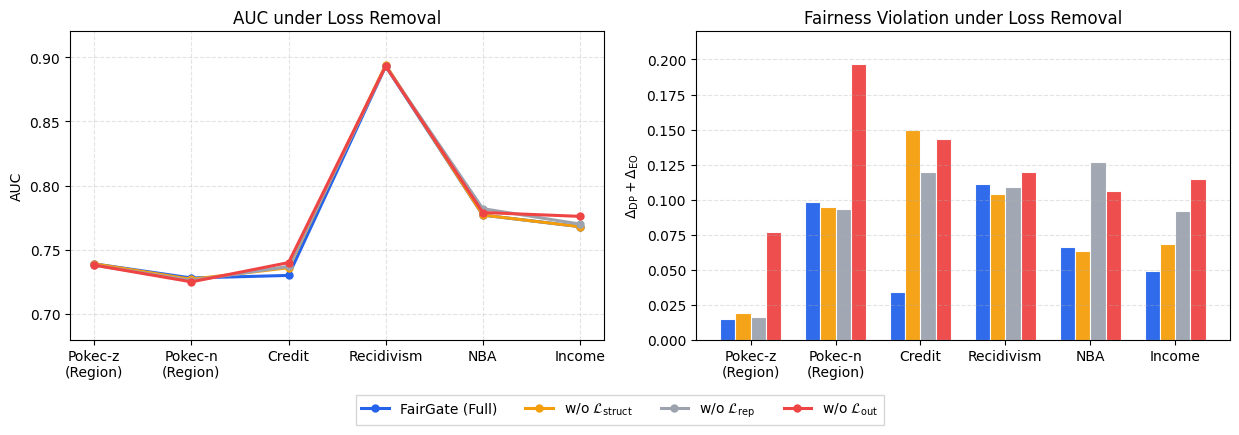

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 0. Save directory
# -----------------------------
os.makedirs("./outputs/figures", exist_ok=True)

# -----------------------------
# 1. Ablation table values
# -----------------------------
datasets = [
    "Pokec-z\n(Region)",
    "Pokec-n\n(Region)",
    "Credit",
    "Recidivism",
    "NBA",
    "Income",
]

data = {
    "Dataset": datasets,

    "Full_AUC": [0.739, 0.728, 0.730, 0.893, 0.777, 0.768],
    "Full_Fair": [0.015, 0.098, 0.034, 0.111, 0.066, 0.049],

    "R1_AUC": [0.739, 0.727, 0.736, 0.894, 0.777, 0.768],
    "R1_Fair": [0.019, 0.095, 0.150, 0.104, 0.063, 0.068],

    "R2_AUC": [0.738, 0.726, 0.737, 0.893, 0.782, 0.770],
    "R2_Fair": [0.016, 0.093, 0.120, 0.109, 0.127, 0.092],

    "R3_AUC": [0.738, 0.725, 0.740, 0.893, 0.779, 0.776],
    "R3_Fair": [0.077, 0.197, 0.143, 0.120, 0.106, 0.115],
}

df = pd.DataFrame(data)

# -----------------------------
# 2. Method definitions
# -----------------------------
methods = {
    "FairGate (Full)": ("Full_AUC", "Full_Fair"),
    r"w/o $\mathcal{L}_{\mathrm{struct}}$": ("R1_AUC", "R1_Fair"),
    r"w/o $\mathcal{L}_{\mathrm{rep}}$": ("R2_AUC", "R2_Fair"),
    r"w/o $\mathcal{L}_{\mathrm{out}}$": ("R3_AUC", "R3_Fair"),
}

colors = {
    "FairGate (Full)": "#2563EB",                         # blue
    r"w/o $\mathcal{L}_{\mathrm{struct}}$": "#F59E0B",   # amber
    r"w/o $\mathcal{L}_{\mathrm{rep}}$": "#9CA3AF",      # gray
    r"w/o $\mathcal{L}_{\mathrm{out}}$": "#EF4444",      # red
}

# -----------------------------
# 3. Side-by-side visualization
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

# -----------------------------
# Left: AUC line plot
# -----------------------------
for name, (auc_col, _) in methods.items():
    axes[0].plot(
        df["Dataset"],
        df[auc_col],
        marker="o",
        linewidth=2.2,
        markersize=5,
        label=name,
        color=colors[name],
    )

axes[0].set_title("AUC under Loss Removal", fontsize=12)
axes[0].set_ylabel("AUC")
# axes[0].set_xlabel("Dataset")
axes[0].grid(True, linestyle="--", alpha=0.35)
axes[0].tick_params(axis="x", rotation=0)
axes[0].set_ylim(0.68, 0.92)

# -----------------------------
# Right: Fairness violation grouped bar chart
# -----------------------------
x = np.arange(len(df["Dataset"]))
n_methods = len(methods)
bar_width = 0.18

for i, (name, (_, fair_col)) in enumerate(methods.items()):
    offset = (i - (n_methods - 1) / 2) * bar_width
    axes[1].bar(
        x + offset,
        df[fair_col],
        width=bar_width,
        label=name,
        color=colors[name],
        alpha=0.95,
        edgecolor="white",
        linewidth=0.8,
    )

axes[1].set_title("Fairness Violation under Loss Removal", fontsize=12)
axes[1].set_ylabel(r"$\Delta_{\mathrm{DP}}+\Delta_{\mathrm{EO}}$")
# axes[1].set_xlabel("Dataset")
axes[1].set_xticks(x)
axes[1].set_xticklabels(df["Dataset"])
axes[1].grid(True, axis="y", linestyle="--", alpha=0.35)
axes[1].set_ylim(0.0, 0.22)

# -----------------------------
# 4. Shared legend at bottom with box
# -----------------------------
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.005),
    ncol=6,
    frameon=True,
    fancybox=False,
    fontsize=10,
)

# Adjust layout to leave room for the bottom legend
plt.tight_layout(rect=[0, 0.09, 1, 1])

# -----------------------------
# 5. Save
# -----------------------------
plt.savefig("./outputs/figures/exp_ablation.pdf", bbox_inches="tight")
plt.savefig("./outputs/figures/exp_ablation.png", dpi=300, bbox_inches="tight")

plt.show()

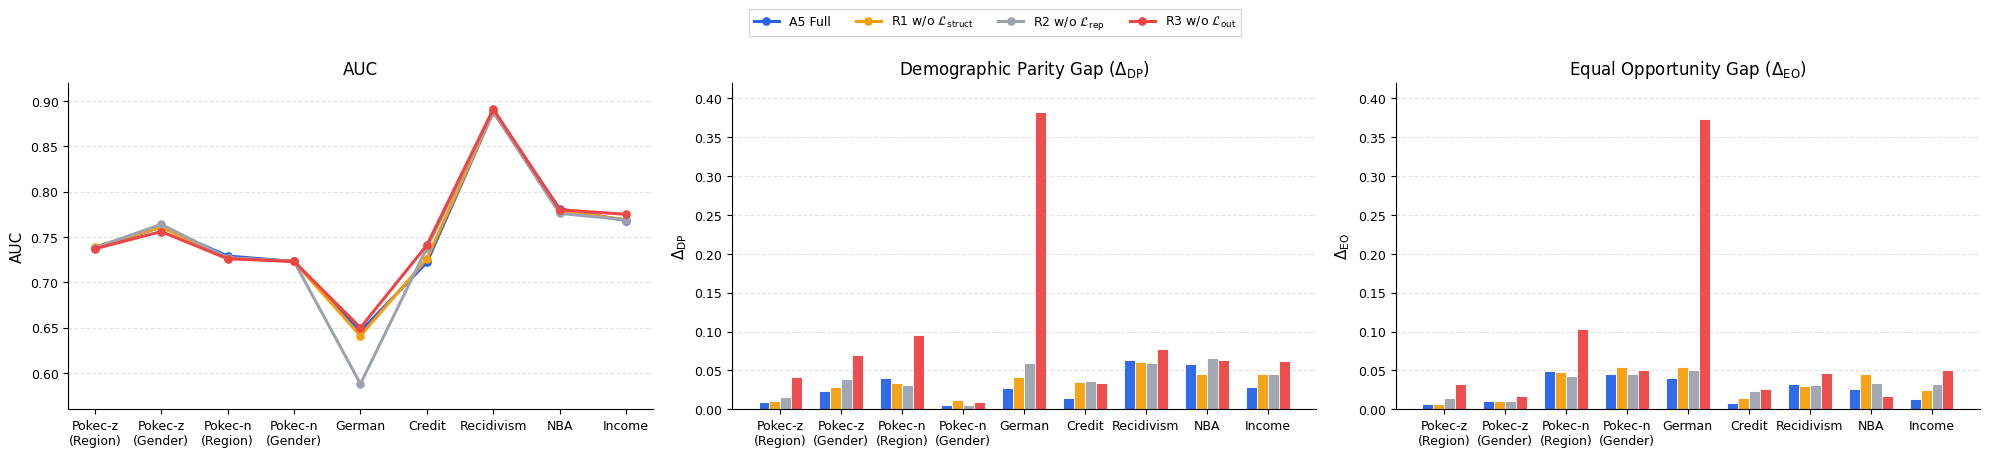

In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 0. Save directory
# -----------------------------
os.makedirs("./outputs/figures", exist_ok=True)

# -----------------------------
# 1. Main-paper ablation results
#    Use only A5 / R1 / R2 / R3 for clarity
# -----------------------------
datasets = [
    "Pokec-z\n(Region)",
    "Pokec-z\n(Gender)",
    "Pokec-n\n(Region)",
    "Pokec-n\n(Gender)",
    "German",
    "Credit",
    "Recidivism",
    "NBA",
    "Income",
]

data = {
    "Dataset": datasets,

    # A5: Full FairGate with Adaptive FIW
    "A5_AUC": [0.738, 0.761, 0.729, 0.723, 0.646, 0.722, 0.888, 0.781, 0.768],
    "A5_DP":  [0.009, 0.023, 0.040, 0.005, 0.028, 0.015, 0.064, 0.058, 0.029],
    "A5_EO":  [0.007, 0.011, 0.049, 0.046, 0.040, 0.008, 0.032, 0.026, 0.013],

    # R1: w/o L_struct
    "R1_AUC": [0.739, 0.761, 0.727, 0.723, 0.641, 0.726, 0.888, 0.779, 0.769],
    "R1_DP":  [0.011, 0.029, 0.034, 0.012, 0.041, 0.035, 0.061, 0.045, 0.045],
    "R1_EO":  [0.007, 0.011, 0.048, 0.054, 0.055, 0.015, 0.030, 0.046, 0.025],

    # R2: w/o L_rep
    "R2_AUC": [0.738, 0.764, 0.727, 0.723, 0.588, 0.738, 0.888, 0.776, 0.769],
    "R2_DP":  [0.016, 0.039, 0.031, 0.006, 0.060, 0.036, 0.060, 0.066, 0.046],
    "R2_EO":  [0.014, 0.011, 0.043, 0.046, 0.051, 0.023, 0.031, 0.034, 0.032],

    # R3: w/o L_out
    "R3_AUC": [0.737, 0.756, 0.726, 0.723, 0.650, 0.741, 0.891, 0.780, 0.775],
    "R3_DP":  [0.041, 0.070, 0.095, 0.009, 0.383, 0.034, 0.077, 0.064, 0.062],
    "R3_EO":  [0.032, 0.017, 0.103, 0.051, 0.374, 0.026, 0.047, 0.017, 0.051],
}

df = pd.DataFrame(data)

# -----------------------------
# 2. Method definitions
# -----------------------------
methods = {
    "A5 Full": ("A5_AUC", "A5_DP", "A5_EO"),
    r"R1 w/o $\mathcal{L}_{\mathrm{struct}}$": ("R1_AUC", "R1_DP", "R1_EO"),
    r"R2 w/o $\mathcal{L}_{\mathrm{rep}}$": ("R2_AUC", "R2_DP", "R2_EO"),
    r"R3 w/o $\mathcal{L}_{\mathrm{out}}$": ("R3_AUC", "R3_DP", "R3_EO"),
}

colors = {
    "A5 Full": "#2563EB",                               # blue
    r"R1 w/o $\mathcal{L}_{\mathrm{struct}}$": "#F59E0B",  # amber
    r"R2 w/o $\mathcal{L}_{\mathrm{rep}}$": "#9CA3AF",     # gray
    r"R3 w/o $\mathcal{L}_{\mathrm{out}}$": "#EF4444",     # red
}

# -----------------------------
# 3. Plot setup
# -----------------------------
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

fig, axes = plt.subplots(1, 3, figsize=(20, 4.5))
x = np.arange(len(df["Dataset"]))
bar_width = 0.18

# -----------------------------
# 4. Panel 1: AUC line plot
# -----------------------------
for name, (auc_col, _, _) in methods.items():
    axes[0].plot(
        x,
        df[auc_col],
        marker="o",
        linewidth=2.2,
        markersize=5.2,
        color=colors[name],
        label=name,
    )

axes[0].set_title("AUC")
axes[0].set_ylabel("AUC")
axes[0].set_xticks(x)
axes[0].set_xticklabels(df["Dataset"])
axes[0].set_ylim(0.56, 0.92)
axes[0].grid(True, axis="y", linestyle="--", alpha=0.35)
axes[0].set_axisbelow(True)

# -----------------------------
# 5. Panel 2: DP grouped bars
# -----------------------------
for i, (name, (_, dp_col, _)) in enumerate(methods.items()):
    offset = (i - 1.5) * bar_width
    axes[1].bar(
        x + offset,
        df[dp_col],
        width=bar_width,
        color=colors[name],
        edgecolor="white",
        linewidth=0.7,
        alpha=0.95,
    )

axes[1].set_title(r"Demographic Parity Gap ($\Delta_{\mathrm{DP}}$)")
axes[1].set_ylabel(r"$\Delta_{\mathrm{DP}}$")
axes[1].set_xticks(x)
axes[1].set_xticklabels(df["Dataset"])
axes[1].set_ylim(0.0, 0.42)
axes[1].grid(True, axis="y", linestyle="--", alpha=0.35)
axes[1].set_axisbelow(True)

# -----------------------------
# 6. Panel 3: EO grouped bars
# -----------------------------
for i, (name, (_, _, eo_col)) in enumerate(methods.items()):
    offset = (i - 1.5) * bar_width
    axes[2].bar(
        x + offset,
        df[eo_col],
        width=bar_width,
        color=colors[name],
        edgecolor="white",
        linewidth=0.7,
        alpha=0.95,
    )

axes[2].set_title(r"Equal Opportunity Gap ($\Delta_{\mathrm{EO}}$)")
axes[2].set_ylabel(r"$\Delta_{\mathrm{EO}}$")
axes[2].set_xticks(x)
axes[2].set_xticklabels(df["Dataset"])
axes[2].set_ylim(0.0, 0.42)
axes[2].grid(True, axis="y", linestyle="--", alpha=0.35)
axes[2].set_axisbelow(True)

# -----------------------------
# 7. Cleaner axes
# -----------------------------
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# -----------------------------
# 8. Legend
# -----------------------------
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=4,
    frameon=True,
    fancybox=False,
)

# -----------------------------
# 9. Layout and save
# -----------------------------
plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.savefig("./outputs/figures/exp_ablation_main.pdf", bbox_inches="tight")
plt.savefig("./outputs/figures/exp_ablation_main.png", dpi=300, bbox_inches="tight")
plt.show()

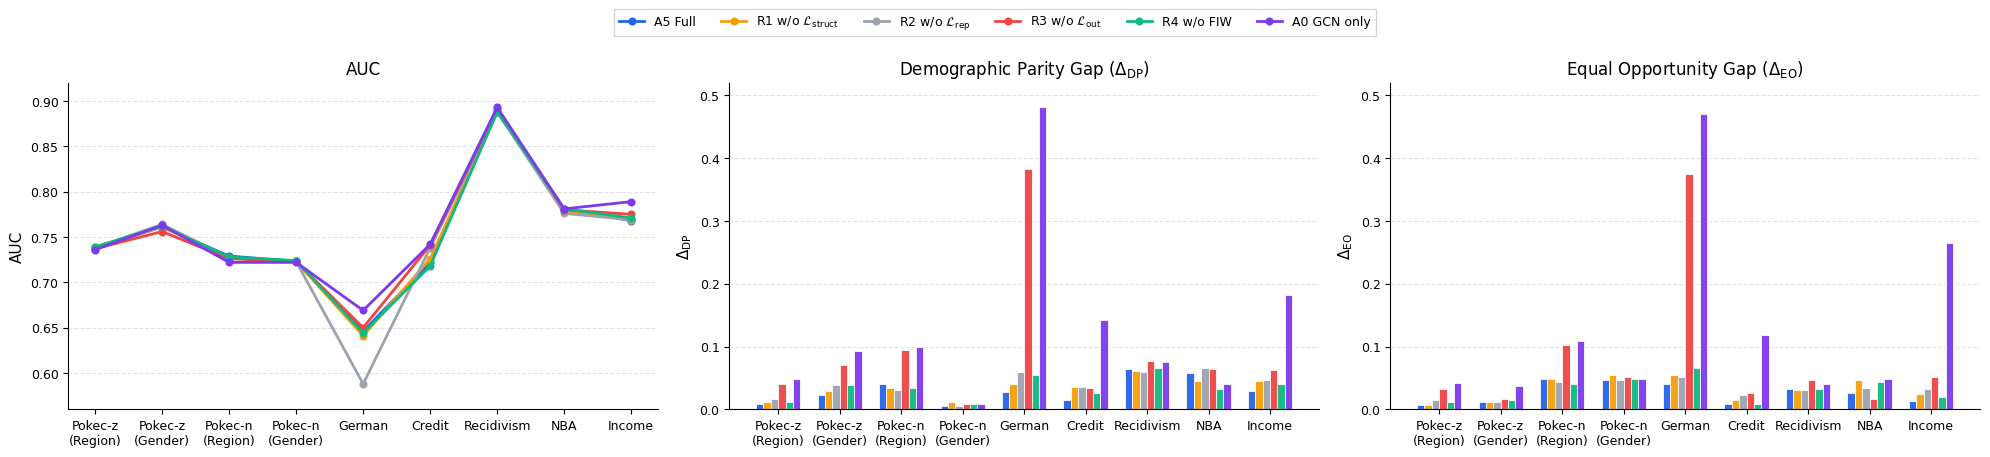

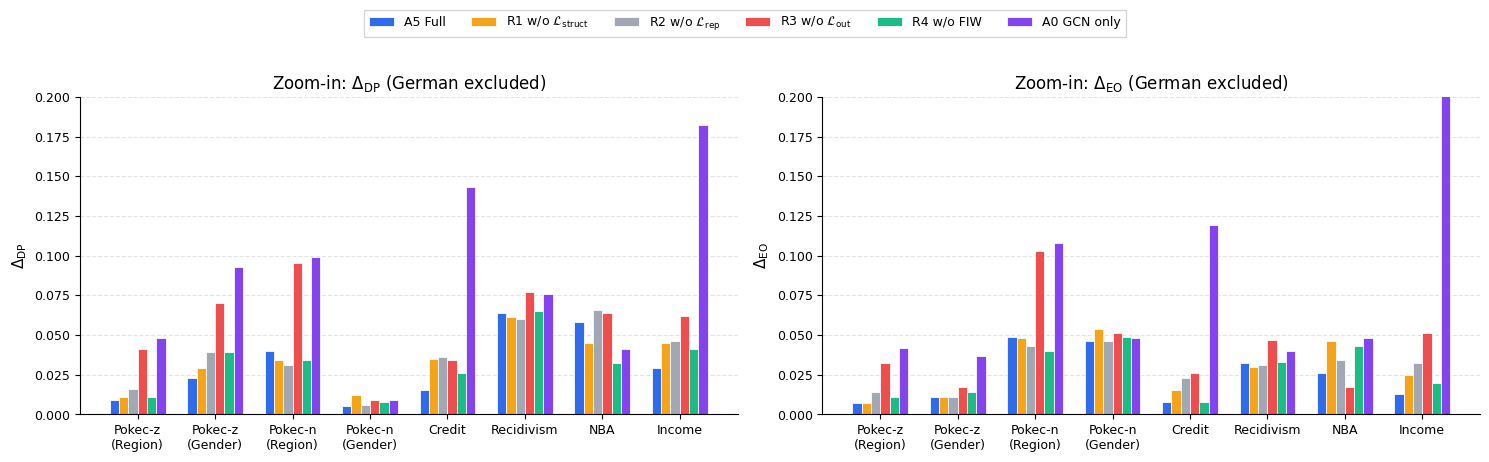

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 0. Save directory
# --------------------------------------------------
os.makedirs("./outputs/figures", exist_ok=True)

# --------------------------------------------------
# 1. Full ablation results (appendix version)
#    A5 / R1 / R2 / R3 / R4 / A0
# --------------------------------------------------
datasets = [
    "Pokec-z\n(Region)",
    "Pokec-z\n(Gender)",
    "Pokec-n\n(Region)",
    "Pokec-n\n(Gender)",
    "German",
    "Credit",
    "Recidivism",
    "NBA",
    "Income",
]

data = {
    "Dataset": datasets,

    # A5: Full FairGate with Adaptive FIW
    "A5_AUC": [0.738, 0.761, 0.729, 0.723, 0.646, 0.722, 0.888, 0.781, 0.768],
    "A5_DP":  [0.009, 0.023, 0.040, 0.005, 0.028, 0.015, 0.064, 0.058, 0.029],
    "A5_EO":  [0.007, 0.011, 0.049, 0.046, 0.040, 0.008, 0.032, 0.026, 0.013],

    # R1: w/o L_struct
    "R1_AUC": [0.739, 0.761, 0.727, 0.723, 0.641, 0.726, 0.888, 0.779, 0.769],
    "R1_DP":  [0.011, 0.029, 0.034, 0.012, 0.041, 0.035, 0.061, 0.045, 0.045],
    "R1_EO":  [0.007, 0.011, 0.048, 0.054, 0.055, 0.015, 0.030, 0.046, 0.025],

    # R2: w/o L_rep
    "R2_AUC": [0.738, 0.764, 0.727, 0.723, 0.588, 0.738, 0.888, 0.776, 0.769],
    "R2_DP":  [0.016, 0.039, 0.031, 0.006, 0.060, 0.036, 0.060, 0.066, 0.046],
    "R2_EO":  [0.014, 0.011, 0.043, 0.046, 0.051, 0.023, 0.031, 0.034, 0.032],

    # R3: w/o L_out
    "R3_AUC": [0.737, 0.756, 0.726, 0.723, 0.650, 0.741, 0.891, 0.780, 0.775],
    "R3_DP":  [0.041, 0.070, 0.095, 0.009, 0.383, 0.034, 0.077, 0.064, 0.062],
    "R3_EO":  [0.032, 0.017, 0.103, 0.051, 0.374, 0.026, 0.047, 0.017, 0.051],

    # R4: w/o FIW
    "R4_AUC": [0.739, 0.762, 0.728, 0.724, 0.644, 0.718, 0.888, 0.781, 0.771],
    "R4_DP":  [0.011, 0.039, 0.034, 0.008, 0.055, 0.026, 0.065, 0.032, 0.041],
    "R4_EO":  [0.011, 0.014, 0.040, 0.049, 0.065, 0.008, 0.033, 0.043, 0.020],

    # A0: GCN only
    "A0_AUC": [0.736, 0.763, 0.722, 0.722, 0.669, 0.742, 0.893, 0.781, 0.789],
    "A0_DP":  [0.048, 0.093, 0.099, 0.009, 0.482, 0.143, 0.076, 0.041, 0.182],
    "A0_EO":  [0.042, 0.037, 0.108, 0.048, 0.471, 0.119, 0.040, 0.048, 0.265],
}

df = pd.DataFrame(data)

# --------------------------------------------------
# 2. Method definitions
# --------------------------------------------------
methods = {
    "A5 Full": ("A5_AUC", "A5_DP", "A5_EO"),
    r"R1 w/o $\mathcal{L}_{\mathrm{struct}}$": ("R1_AUC", "R1_DP", "R1_EO"),
    r"R2 w/o $\mathcal{L}_{\mathrm{rep}}$": ("R2_AUC", "R2_DP", "R2_EO"),
    r"R3 w/o $\mathcal{L}_{\mathrm{out}}$": ("R3_AUC", "R3_DP", "R3_EO"),
    "R4 w/o FIW": ("R4_AUC", "R4_DP", "R4_EO"),
    "A0 GCN only": ("A0_AUC", "A0_DP", "A0_EO"),
}

colors = {
    "A5 Full": "#2563EB",                               # blue
    r"R1 w/o $\mathcal{L}_{\mathrm{struct}}$": "#F59E0B",  # amber
    r"R2 w/o $\mathcal{L}_{\mathrm{rep}}$": "#9CA3AF",     # gray
    r"R3 w/o $\mathcal{L}_{\mathrm{out}}$": "#EF4444",     # red
    "R4 w/o FIW": "#10B981",                            # green
    "A0 GCN only": "#7C3AED",                           # purple
}

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

# ==================================================
# Figure 1: Full appendix figure (3-panel)
# ==================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 4.5))
x = np.arange(len(df["Dataset"]))
n_methods = len(methods)
bar_width = 0.12

# --------------------------
# Panel 1: AUC
# --------------------------
for name, (auc_col, _, _) in methods.items():
    axes[0].plot(
        x,
        df[auc_col],
        marker="o",
        linewidth=2.0,
        markersize=4.8,
        color=colors[name],
        label=name,
    )

axes[0].set_title("AUC")
axes[0].set_ylabel("AUC")
axes[0].set_xticks(x)
axes[0].set_xticklabels(df["Dataset"])
axes[0].set_ylim(0.56, 0.92)
axes[0].grid(True, axis="y", linestyle="--", alpha=0.35)
axes[0].set_axisbelow(True)

# --------------------------
# Panel 2: DP
# --------------------------
for i, (name, (_, dp_col, _)) in enumerate(methods.items()):
    offset = (i - (n_methods - 1) / 2) * bar_width
    axes[1].bar(
        x + offset,
        df[dp_col],
        width=bar_width,
        color=colors[name],
        edgecolor="white",
        linewidth=0.6,
        alpha=0.95,
    )

axes[1].set_title(r"Demographic Parity Gap ($\Delta_{\mathrm{DP}}$)")
axes[1].set_ylabel(r"$\Delta_{\mathrm{DP}}$")
axes[1].set_xticks(x)
axes[1].set_xticklabels(df["Dataset"])
axes[1].set_ylim(0.0, 0.52)
axes[1].grid(True, axis="y", linestyle="--", alpha=0.35)
axes[1].set_axisbelow(True)

# --------------------------
# Panel 3: EO
# --------------------------
for i, (name, (_, _, eo_col)) in enumerate(methods.items()):
    offset = (i - (n_methods - 1) / 2) * bar_width
    axes[2].bar(
        x + offset,
        df[eo_col],
        width=bar_width,
        color=colors[name],
        edgecolor="white",
        linewidth=0.6,
        alpha=0.95,
    )

axes[2].set_title(r"Equal Opportunity Gap ($\Delta_{\mathrm{EO}}$)")
axes[2].set_ylabel(r"$\Delta_{\mathrm{EO}}$")
axes[2].set_xticks(x)
axes[2].set_xticklabels(df["Dataset"])
axes[2].set_ylim(0.0, 0.52)
axes[2].grid(True, axis="y", linestyle="--", alpha=0.35)
axes[2].set_axisbelow(True)

# Clean spines
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=6,
    frameon=True,
    fancybox=False,
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("./outputs/figures/exp_ablation_appendix_full.pdf", bbox_inches="tight")
plt.savefig("./outputs/figures/exp_ablation_appendix_full.png", dpi=300, bbox_inches="tight")
plt.show()

# ==================================================
# Figure 2: Zoom-in fairness figure
#   - German excluded
#   - fairness only
# ==================================================
zoom_df = df[df["Dataset"] != "German"].reset_index(drop=True)
x_zoom = np.arange(len(zoom_df["Dataset"]))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

# --------------------------
# Zoom Panel 1: DP
# --------------------------
for i, (name, (_, dp_col, _)) in enumerate(methods.items()):
    offset = (i - (n_methods - 1) / 2) * bar_width
    axes[0].bar(
        x_zoom + offset,
        zoom_df[dp_col],
        width=bar_width,
        color=colors[name],
        edgecolor="white",
        linewidth=0.6,
        alpha=0.95,
        label=name,
    )

axes[0].set_title(r"Zoom-in: $\Delta_{\mathrm{DP}}$ (German excluded)")
axes[0].set_ylabel(r"$\Delta_{\mathrm{DP}}$")
axes[0].set_xticks(x_zoom)
axes[0].set_xticklabels(zoom_df["Dataset"])
axes[0].set_ylim(0.0, 0.20)
axes[0].grid(True, axis="y", linestyle="--", alpha=0.35)
axes[0].set_axisbelow(True)

# --------------------------
# Zoom Panel 2: EO
# --------------------------
for i, (name, (_, _, eo_col)) in enumerate(methods.items()):
    offset = (i - (n_methods - 1) / 2) * bar_width
    axes[1].bar(
        x_zoom + offset,
        zoom_df[eo_col],
        width=bar_width,
        color=colors[name],
        edgecolor="white",
        linewidth=0.6,
        alpha=0.95,
        label=name,
    )

axes[1].set_title(r"Zoom-in: $\Delta_{\mathrm{EO}}$ (German excluded)")
axes[1].set_ylabel(r"$\Delta_{\mathrm{EO}}$")
axes[1].set_xticks(x_zoom)
axes[1].set_xticklabels(zoom_df["Dataset"])
axes[1].set_ylim(0.0, 0.20)
axes[1].grid(True, axis="y", linestyle="--", alpha=0.35)
axes[1].set_axisbelow(True)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=6,
    frameon=True,
    fancybox=False,
)

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.savefig("./outputs/figures/exp_ablation_appendix_zoom.pdf", bbox_inches="tight")
plt.savefig("./outputs/figures/exp_ablation_appendix_zoom.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Acc-Fairness trade-off curve
# λ_fair sweep으로 Pareto frontier 시각화. "FairGate가 baseline 대비 frontier 자체를 개선한다"는 주장의 직접 근거. 리뷰어가 가장 인상깊게 보는 figure.
!python run_tradeoff.py \
    --datasets pokec_z pokec_z_g pokec_n pokec_n_g german credit recidivism nba income

!python outputs/analysis/tradeoff_plot.py

In [ ]:
# FIW gating 분석
# adaptive gating 설계(w_lhd 혼합)가 실제로 어떻게 작동하는지 시각적으로 보여줌. 모델 수정 후 결과가 달라졌으므로 반드시 재실행 필요.
!python analyze_fiw_gating.py \
    --datasets pokec_z pokec_z_g pokec_n pokec_n_g german credit recidivism nba income \
    --device cuda:1

#### 설계 검증 실험

In [ ]:
# Scale calibration 분석
# periodic recalibration vs warmup-only vs no-calibration 비교. 설계 결정의 정당성. Phase 1 완료 후 실행.
!python analyze_scale_calibration.py \
    --datasets pokec_z pokec_z_g pokec_n pokec_n_g german credit recidivism nba income \
    --conditions with_calibration warmup_only no_calibration \
    --output_dir outputs/analysis \
    --log_dir logs/scale_calibration

!python outputs/analysis/scale_calibration_plot.py


In [58]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Scale calibration values
# -----------------------------
datasets = [
    "Pokec-z\n(Region)",
    "Pokec-z\n(Gender)",
    "Pokec-n\n(Region)",
    "Pokec-n\n(Gender)",
    "German",
    "Credit",
    "Recidivism",
    "NBA",
    "Income",
]

data = {
    "Dataset": datasets,

    # NC: no warm-up, no calibration
    "NC_AUC":  [0.738, 0.766, 0.726, 0.722, 0.614, 0.745, 0.893, 0.773, 0.781],
    "NC_Fair": [0.006, 0.055, 0.128, 0.056, 0.295, 0.214, 0.119, 0.096, 0.209],

    # WO: warm-up only
    "WO_AUC":  [0.739, 0.763, 0.725, 0.723, 0.602, 0.731, 0.890, 0.774, 0.766],
    "WO_Fair": [0.024, 0.033, 0.085, 0.069, 0.123, 0.051, 0.115, 0.032, 0.091],

    # WC: warm-up + calibration
    "WC_AUC":  [0.739, 0.762, 0.729, 0.724, 0.663, 0.730, 0.893, 0.774, 0.768],
    "WC_Fair": [0.020, 0.053, 0.094, 0.057, 0.018, 0.030, 0.111, 0.032, 0.055],
}

df = pd.DataFrame(data)

# -----------------------------
# 2. Condition definitions
# -----------------------------
labels = datasets
x = list(range(len(labels)))

series = {
    "NC": {
        "auc": df["NC_AUC"].tolist(),
        "fair": df["NC_Fair"].tolist(),
        "color": "#9CA3AF",   # gray
    },
    "WO": {
        "auc": df["WO_AUC"].tolist(),
        "fair": df["WO_Fair"].tolist(),
        "color": "#F59E0B",   # amber
    },
    "WC (Full)": {
        "auc": df["WC_AUC"].tolist(),
        "fair": df["WC_Fair"].tolist(),
        "color": "#2563EB",   # blue
    },
}

# -----------------------------
# 3. Create output directory
# -----------------------------
save_dir = "./outputs/figures"
os.makedirs(save_dir, exist_ok=True)

# -----------------------------
# 4. Plot
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(15.5, 4.5))

# -------- Left: AUC --------
for name, vals in series.items():
    axes[0].plot(
        x,
        vals["auc"],
        marker="o",
        linewidth=2.2,
        markersize=5,
        color=vals["color"],
        label=name,
    )

axes[0].set_title("AUC across Calibration Settings", fontsize=12)
axes[0].set_ylabel("AUC")
axes[0].set_xlabel("Dataset")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].grid(True, linestyle="--", alpha=0.35)
axes[0].set_ylim(0.58, 0.92)

# -------- Right: Fairness --------
for name, vals in series.items():
    axes[1].plot(
        x,
        vals["fair"],
        marker="o",
        linewidth=2.2,
        markersize=5,
        color=vals["color"],
        label=name,
    )

axes[1].set_title("Fairness Violation across Calibration Settings", fontsize=12)
axes[1].set_ylabel(r"$\Delta_{\mathrm{DP}}+\Delta_{\mathrm{EO}}$")
axes[1].set_xlabel("Dataset")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].grid(True, linestyle="--", alpha=0.35)
axes[1].set_ylim(0.0, 0.32)

# -----------------------------
# 5. Legend inside the right subplot
# -----------------------------
axes[1].legend(
    loc="upper right",
    ncol=1,
    frameon=True,
    fancybox=False,
    framealpha=0.95,
    # edgecolor="black",
    fontsize=9,
)

plt.tight_layout()

# -----------------------------
# 6. Save
# -----------------------------
plt.savefig(f"{save_dir}/scale_calibration.pdf", bbox_inches="tight")
plt.savefig(f"{save_dir}/scale_calibration.png", dpi=300, bbox_inches="tight")

plt.show()

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Scale calibration values
#    NC: no warm-up, no calibration
#    WO: warm-up only
#    WC: warm-up + scale calibration
# -----------------------------
datasets = [
    "Pokec-z\n(Region)",
    "Pokec-z\n(Gender)",
    "Pokec-n\n(Region)",
    "Pokec-n\n(Gender)",
    "German",
    "Credit",
    "Recidivism",
    "NBA",
    "Income",
]

data = {
    "Dataset": datasets,

    # NC: no warm-up, no calibration
    "NC_AUC":  [0.756, 0.768, 0.740, 0.725, 0.574, 0.724, 0.894, 0.778, 0.598],
    "NC_Fair": [0.059, 0.058, 0.178, 0.066, 0.107, 0.099, 0.121, 0.117, 0.007],

    # WO: warm-up only
    "WO_AUC":  [0.738, 0.765, 0.725, 0.724, 0.601, 0.743, 0.892, 0.777, 0.774],
    "WO_Fair": [0.015, 0.077, 0.127, 0.062, 0.209, 0.056, 0.109, 0.099, 0.198],

    # WC: warm-up + scale calibration
    "WC_AUC":  [0.739, 0.760, 0.729, 0.725, 0.649, 0.728, 0.888, 0.779, 0.768],
    "WC_Fair": [0.018, 0.049, 0.090, 0.059, 0.032, 0.023, 0.096, 0.081, 0.050],
}

df = pd.DataFrame(data)

# Optional sanity check: average values used in the paper table
avg = pd.DataFrame({
    "Setting": ["NC", "WO", "WC"],
    "AUC": [
        df["NC_AUC"].mean(),
        df["WO_AUC"].mean(),
        df["WC_AUC"].mean(),
    ],
    "Fair": [
        df["NC_Fair"].mean(),
        df["WO_Fair"].mean(),
        df["WC_Fair"].mean(),
    ],
})
print(avg.round(4))

# -----------------------------
# 2. Condition definitions
# -----------------------------
series = {
    "NC": {
        "auc": "NC_AUC",
        "fair": "NC_Fair",
        "color": "#9CA3AF",   # gray
    },
    "WO": {
        "auc": "WO_AUC",
        "fair": "WO_Fair",
        "color": "#F59E0B",   # amber
    },
    "WC (Full)": {
        "auc": "WC_AUC",
        "fair": "WC_Fair",
        "color": "#2563EB",   # blue
    },
}

# -----------------------------
# 3. Create output directory
# -----------------------------
save_dir = "./outputs/figures"
os.makedirs(save_dir, exist_ok=True)

# -----------------------------
# 4. Plot
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

x = np.arange(len(df["Dataset"]))

# -----------------------------
# Left: AUC line plot
# -----------------------------
for name, vals in series.items():
    axes[0].plot(
        x,
        df[vals["auc"]],
        marker="o",
        linewidth=2.2,
        markersize=5.5,
        color=vals["color"],
        label=name,
    )

axes[0].set_title("AUC across Calibration Settings", fontsize=12)
axes[0].set_ylabel("AUC")
axes[0].set_xticks(x)
axes[0].set_xticklabels(df["Dataset"])
axes[0].grid(True, axis="y", linestyle="--", alpha=0.35)
axes[0].set_ylim(0.55, 0.92)
axes[0].set_axisbelow(True)

# -----------------------------
# Right: Fairness grouped bar plot
# -----------------------------
bar_width = 0.24
n_methods = len(series)

for i, (name, vals) in enumerate(series.items()):
    offset = (i - (n_methods - 1) / 2) * bar_width
    axes[1].bar(
        x + offset,
        df[vals["fair"]],
        width=bar_width,
        color=vals["color"],
        label=name,
        alpha=0.95,
        edgecolor="white",
        linewidth=0.8,
    )

axes[1].set_title("Fairness Violation across Calibration Settings", fontsize=12)
axes[1].set_ylabel(r"$\Delta_{\mathrm{DP}}+\Delta_{\mathrm{EO}}$")
axes[1].set_xticks(x)
axes[1].set_xticklabels(df["Dataset"])
axes[1].grid(True, axis="y", linestyle="--", alpha=0.35)
axes[1].set_ylim(0.0, 0.23)
axes[1].set_axisbelow(True)

# -----------------------------
# 5. Cleaner style
# -----------------------------
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# -----------------------------
# 6. Legend inside right subplot
# -----------------------------
axes[1].legend(
    loc="upper right",
    ncol=1,
    frameon=True,
    fancybox=False,
    framealpha=0.95,
    fontsize=9,
)

plt.tight_layout()

# -----------------------------
# 7. Save
# -----------------------------
plt.savefig(f"{save_dir}/exp_calibration.pdf", bbox_inches="tight")
plt.savefig(f"{save_dir}/exp_calibration.png", dpi=300, bbox_inches="tight")

plt.show()

  Setting     AUC    Fair
0      NC  0.7286  0.0902
1      WO  0.7488  0.1058
2      WC  0.7517  0.0553


In [ ]:
# Edge intervention 분석
# drop vs scale. 이미 drop으로 메인 실험 돌렸으므로 scale만 추가 실행하면 됨. graph_stats와 연결해서 regime별 패턴 분석.
!python run_edge_intervention.py \
    --datasets pokec_z pokec_z_g pokec_n pokec_n_g german credit recidivism nba income \
    --interventions drop scale \
    --output_dir outputs/analysis \
    --log_dir logs/edge_intervention


In [ ]:
# sensitivity analysis
# λ_fair, struct_drop, τ(boundary_sat_thr) 등 파라미터 robust성 입증. τ 민감도 분석이 subsec_adaptive_gating.tex 서술을 뒷받침.
!python run_sensitivity.py \
    --datasets pokec_z pokec_z_g pokec_n pokec_n_g german credit recidivism nba income \
    --params lambda_fair struct_drop warm_up dp_eo_ratio sbrs_quantile \
    --output_dir outputs/analysis \
    --log_dir logs/sensitivity
    
!python outputs/analysis/sensitivity_plot.py

#### 보조 분석 실험

In [ ]:
# Backbone 범용성 검증 
# GCN / GraphSAGE / SGC 비교. 이미 결과 있음. 분석만 재실행.
!python analyze_backbone.py \
    --gcn  outputs/exp_fairgate_gcn.csv \
    --sage outputs/exp_fairgate_sage.csv \
    --sgc  outputs/exp_fairgate_sgc.csv
    

In [ ]:
# Graph 구조 특성 분석 
# 이미 완료. adaptive gating 설계 근거 섹션과 연결. 수정된 모델로 FIW gating 분석 완료 후 graph_stats 업데이트만 확인.
# exp_fairgate.csv 있으면 자동 연결
!python analyze_graph_stats.py --fairgate_csv outputs/exp_fairgate_gcn.csv
!python analyze_graph_stats.py --fairgate_csv outputs/exp_fairgate_sc.csv

In [ ]:

# Scalability 분석
# 메인 실험 CSV에서 time_sec 기반 분석. 추가 실험 불필요. 마지막에 실행.
# exp_fairgate.csv 있으면 자동 연결
!python analyze_scalability.py \
        --fairgate_csv outputs/exp_fairgate_gcn.csv \
        --baseline_csv outputs/compare/exp_baselines.csv \
        --graph_stats  outputs/analysis/graph_stats.csv

[Saved] ./outputs/analysis/scalability.pdf


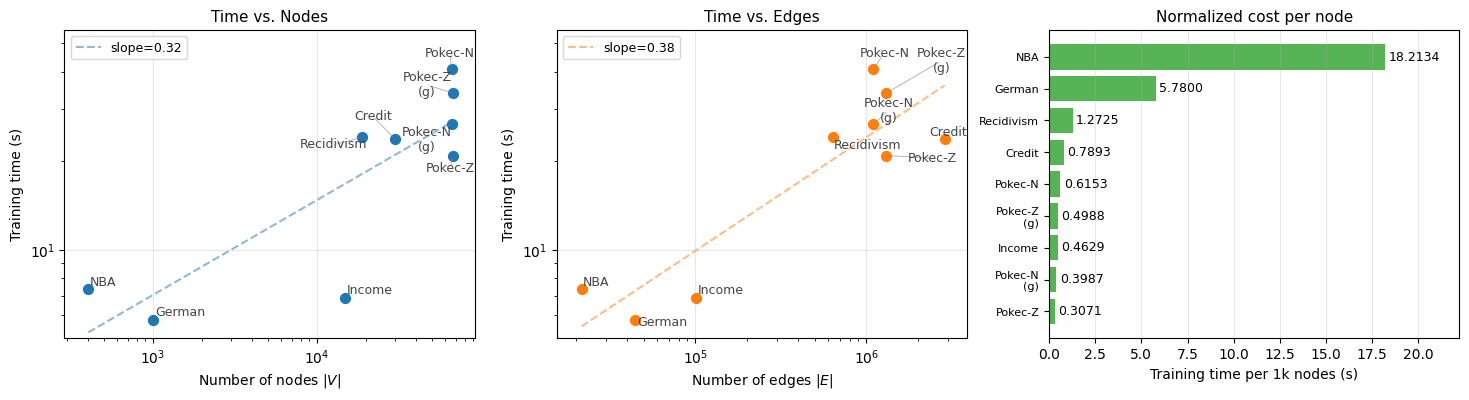

In [17]:
# Scalability 시각화
# !python ./outputs/analysis/scalability_plot.py

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text

df = pd.read_csv(os.path.join('./outputs/analysis', "scalability.csv"))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
# fig.suptitle("FairGate Scalability Analysis", fontsize=13, fontweight="bold", y=1.02)

colors = plt.cm.tab10.colors

def add_scatter_with_repel_labels(ax, x, y, labels, color, xlabel, title):
    ax.scatter(x, y, color=color, s=50, zorder=3)

    # 먼저 축/스케일 설정
    ax.set_xscale("log")
    ax.set_yscale("log")

    # 바깥 여백 확보
    ax.set_xlim(np.min(x) / 1.4, np.max(x) * 1.35)
    ax.set_ylim(np.min(y) / 1.15, np.max(y) * 1.35)

    # 라벨 생성
    texts = []
    for xi, yi, label in zip(x, y, labels):
        label = label.replace(" (gender)", "\n(g)")
        texts.append(
            ax.text(
                xi, yi, label,
                fontsize=9,
                color="#444",
                zorder=4
            )
        )

    # 라벨 자동 충돌 회피
    adjust_text(
        texts,
        ax=ax,
        x=x,
        y=y,
        expand_points=(1.2, 1.4),
        expand_text=(1.2, 1.4),
        force_points=0.35,
        force_text=0.45,
        lim=300,
        arrowprops=dict(
            arrowstyle="-",
            color="#888",
            lw=0.6,
            alpha=0.7
        ),
        ensure_inside_axes=True,
        only_move={"points": "y", "text": "xy"},
    )

    # log-log fit
    lx = np.log(x.astype(float))
    ly = np.log(y.astype(float))
    coeffs = np.polyfit(lx, ly, 1)
    xfit = np.linspace(lx.min(), lx.max(), 100)

    ax.plot(
        np.exp(xfit),
        np.exp(np.polyval(coeffs, xfit)),
        "--",
        color=color,
        alpha=0.5,
        label=f"slope={coeffs[0]:.2f}",
        zorder=2
    )

    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel("Training time (s)", fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)


# ── (1) Nodes vs Time ──────────────────────────────────────────────────────────
add_scatter_with_repel_labels(
    ax=axes[0],
    x=df["nodes"].values.astype(float),
    y=df["time_sec_mean"].values.astype(float),
    labels=df["display_name"].tolist(),
    color=colors[0],
    xlabel="Number of nodes $|V|$",
    title="Time vs. Nodes",
)

# ── (2) Edges vs Time ──────────────────────────────────────────────────────────
add_scatter_with_repel_labels(
    ax=axes[1],
    x=df["edges"].values.astype(float),
    y=df["time_sec_mean"].values.astype(float),
    labels=df["display_name"].tolist(),
    color=colors[1],
    xlabel="Number of edges $|E|$",
    title="Time vs. Edges",
)

# ── (3) Time per 1k nodes (bar) ────────────────────────────────────────────────
ax = axes[2]
bar_df = df.sort_values("time_per_1k_nodes")
bar_labels = bar_df["display_name"].str.replace(" (gender)", "\n(g)", regex=False)

bars = ax.barh(bar_labels, bar_df["time_per_1k_nodes"], color=colors[2], alpha=0.8)

max_val = bar_df["time_per_1k_nodes"].max()
ax.set_xlim(0, max_val * 1.22)
ax.set_xlabel("Training time per 1k nodes (s)", fontsize=10)
ax.set_title("Normalized cost per node", fontsize=11)
ax.grid(True, axis="x", alpha=0.3)
ax.tick_params(axis="y", labelsize=8)

for bar, val in zip(bars, bar_df["time_per_1k_nodes"]):
    ax.text(
        bar.get_width() + max_val * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center",
        ha="left",
        fontsize=9
    )

out = os.path.join('./outputs/analysis', "scalability.pdf")
plt.savefig(out, bbox_inches="tight", dpi=150)
print(f"[Saved] {out}")
plt.show()

In [17]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# ── 데이터 ────────────────────────────────────────────────────────────
MODELS = ['FairGate','FairGNN','NIFTY','FairGT','FairGB',
          'FairVGNN','FairWalk','CrossWalk']

COLORS = {
    'FairGate' : '#2563EB',
    'FairGNN'  : '#9CA3AF',
    'NIFTY'    : '#9CA3AF',
    'FairGT'   : '#9CA3AF',
    'FairGB'   : '#9CA3AF',
    'FairVGNN' : '#F59E0B',
    'FairWalk' : '#EF4444',
    'CrossWalk': '#EF4444',
}

# Pokec-Z epoch당 시간 (ms)
pokec_z = {
    'FairGate': 15.9, 'FairGNN': 11.1, 'NIFTY': 23.8,
    'FairGT': 39.7, 'FairGB': 97.3,
    'FairVGNN': 1739.3, 'FairWalk': 66987.9, 'CrossWalk': 100144.2,
}
# Credit epoch당 시간 (ms)
credit = {
    'FairGate': 45.3, 'FairGNN': 16.7, 'NIFTY': 26.2,
    'FairGT': 24.7, 'FairGB': 92.2,
    'FairVGNN': 1335.4, 'FairWalk': 15063.1, 'CrossWalk': 20807.5,
}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.patch.set_facecolor('white')

for ax, data, title in [
    (axes[0], pokec_z, '(a) Pokec-Z  ($|V|{=}67{,}796$)'),
    (axes[1], credit,  '(b) Credit  ($|V|{=}30{,}000$)'),
]:
    ax.set_facecolor('#FAFAFA')
    vals  = [data[m] for m in MODELS]
    cols  = [COLORS[m] for m in MODELS]
    x     = np.arange(len(MODELS))

    bars = ax.bar(x, vals, color=cols, alpha=0.88,
                  edgecolor='white', linewidth=0.8)

    # 값 표시
    for bar, val in zip(bars, vals):
        h = bar.get_height()
        if val >= 1000:
            label = f'{val/1000:.1f}k'
        elif val >= 100:
            label = f'{val:.0f}'
        else:
            label = f'{val:.1f}'
        ax.text(bar.get_x() + bar.get_width()/2,
                h * 1, label,
                ha='center', va='bottom', fontsize=7.5,
                fontweight='bold' if MODELS[vals.index(val)]=='FairGate' else 'normal',
                color=COLORS[MODELS[vals.index(val)]])

    # FairGate 강조 테두리
    fg_idx = MODELS.index('FairGate')
    bars[fg_idx].set_edgecolor('#1D4ED8')
    bars[fg_idx].set_linewidth(1.8)

    ax.set_yscale('log')
    ax.set_xticks(x)
    ax.set_xticklabels(MODELS, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Time per epoch (ms, log scale)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold', loc='left')
    ax.grid(True, axis='y', alpha=0.2, linestyle='--', which='both')
    for sp in ax.spines.values():
        sp.set_linewidth(0.6)

    # 범례 표시
    from matplotlib.patches import Patch
    legend_els = [
        Patch(color='#2563EB', alpha=0.88, label='FairGate (ours)'),
        Patch(color='#F59E0B', alpha=0.88, label='FairVGNN'),
        Patch(color='#EF4444', alpha=0.88, label='Walk-based'),
        Patch(color='#9CA3AF', alpha=0.88, label='Others'),
    ]
    ax.legend(handles=legend_els, fontsize=8,
              loc='upper left', framealpha=0.9,
              edgecolor='#D1D5DB')

# plt.suptitle('Time per Epoch Comparison (log scale)',
#              fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()

for ext in ['pdf', 'png']:
    fig.savefig(f'./outputs/figures/epoch_time_chart.{ext}',
                bbox_inches='tight', dpi=200)
plt.close()
print("Done")

Done
